
Loading and cleaning data from CWC_VARANASI_WSE_DailyMean.csv...


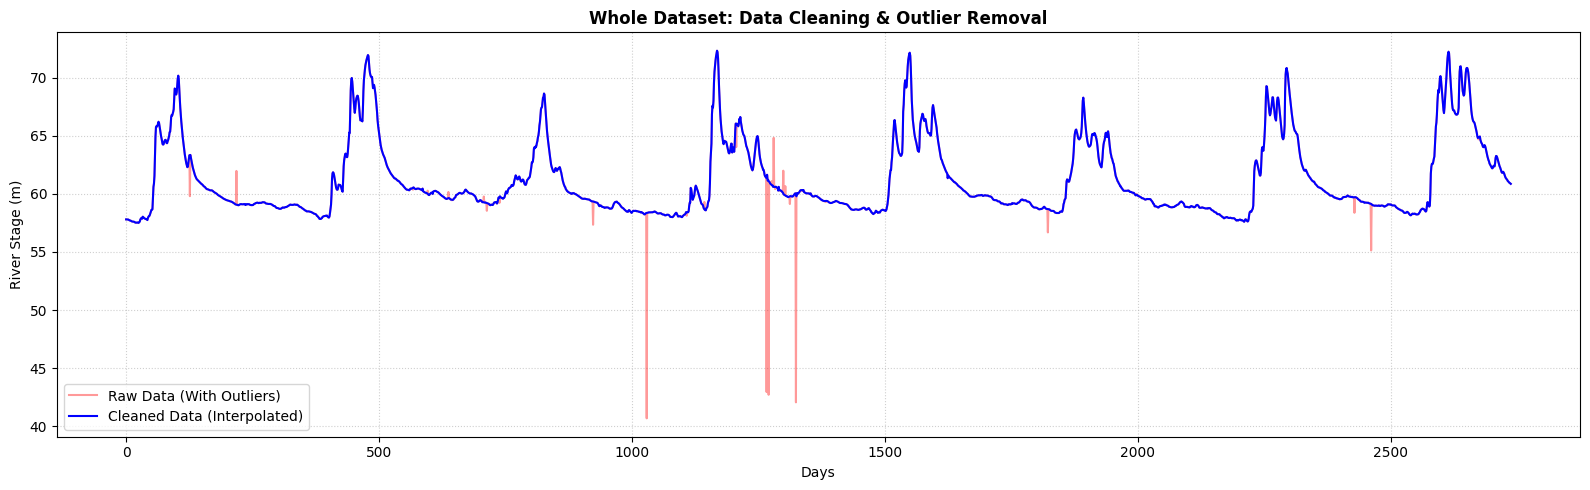


  HORIZON: t+1 Days

  [DWT] Full-length decomposition...
Plotting DWT IMFs for Training Data...


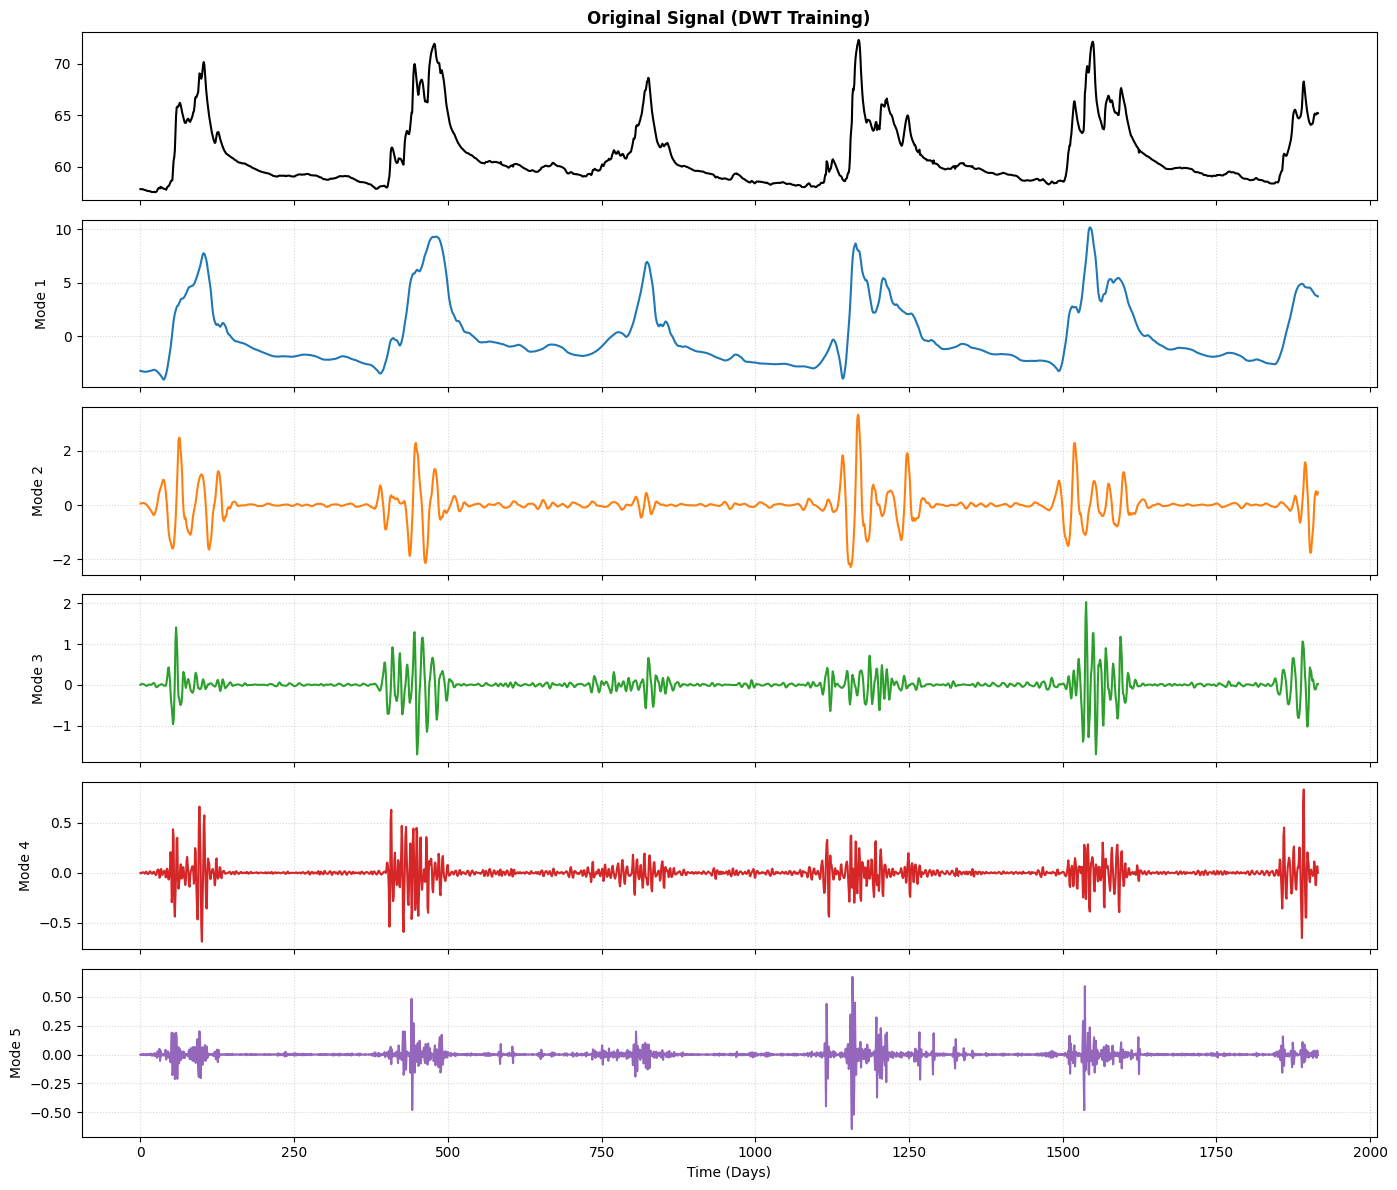

      -> Tuning RFR and XGBoost hyperparameters...
    DWT-RFR: R=0.9863, NSE=0.9569
    DWT-XGB: R=0.9883, NSE=0.9653
    DWT-ANN: R=0.9911, NSE=0.9671
    DWT-LSTM: R=0.9925, NSE=0.9684

  [SST] Full-length decomposition...
Plotting SST IMFs for Training Data...


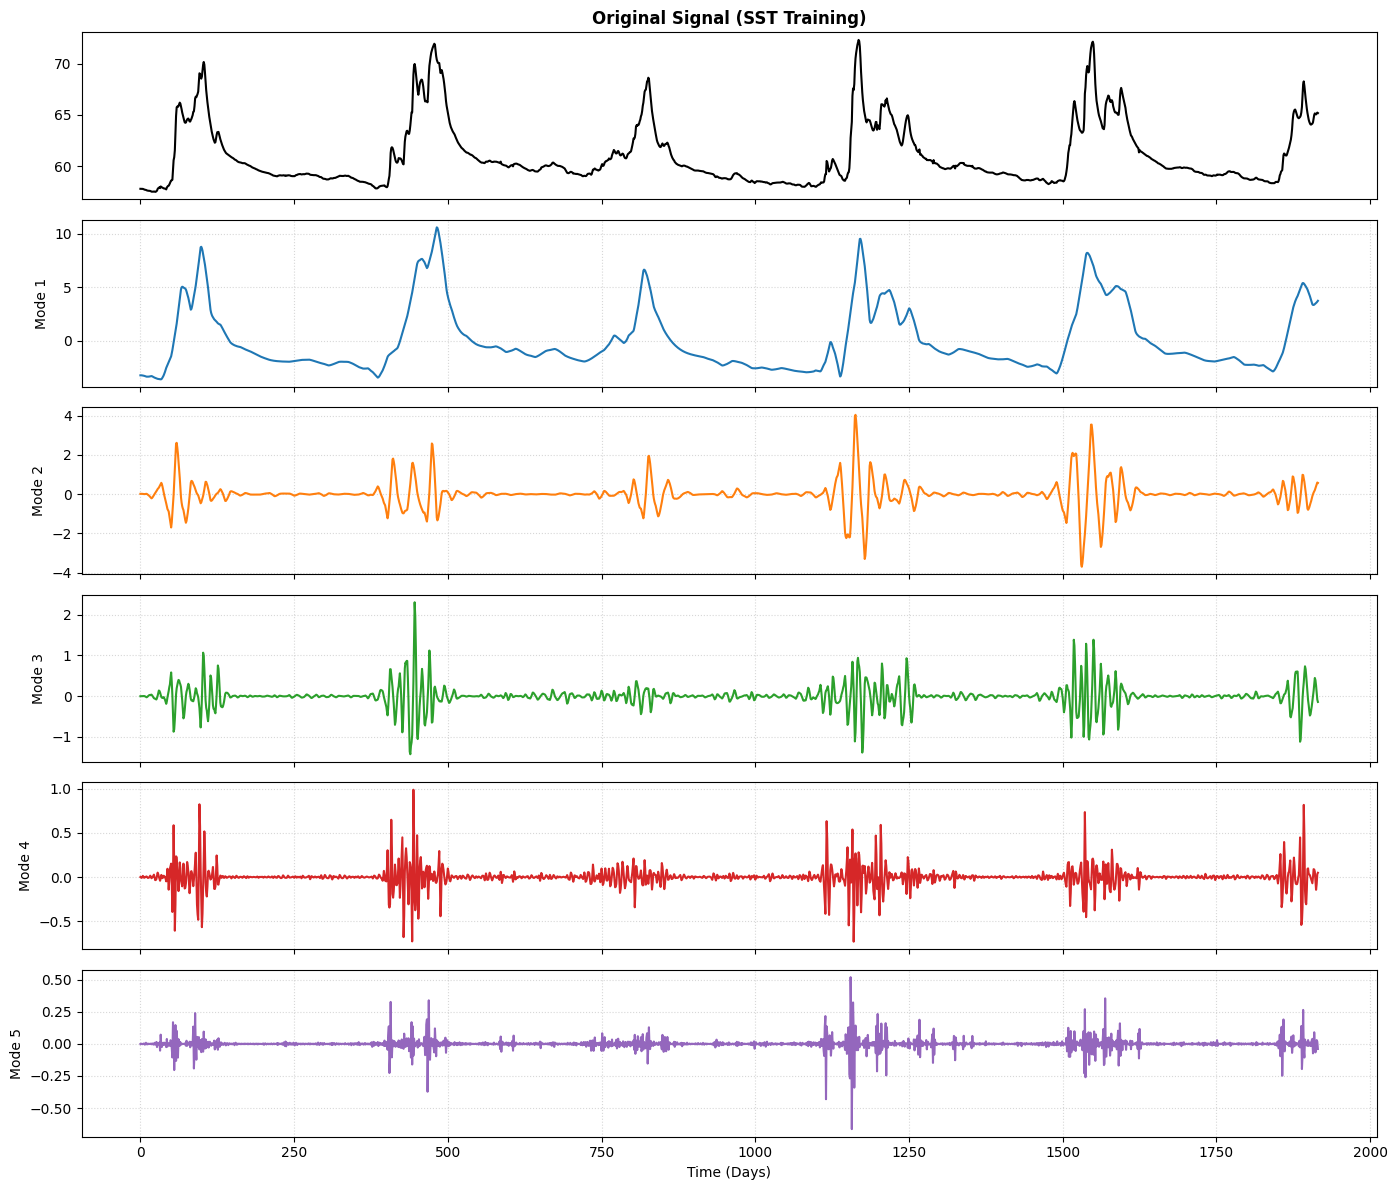

      -> Tuning RFR and XGBoost hyperparameters...
    SST-RFR: R=0.9869, NSE=0.9565
    SST-XGB: R=0.9859, NSE=0.9561
    SST-ANN: R=0.9946, NSE=0.9722
    SST-LSTM: R=0.9947, NSE=0.9724

  [VMD] Rolling 30-day decomposition...
Plotting VMD IMFs for Training Data...


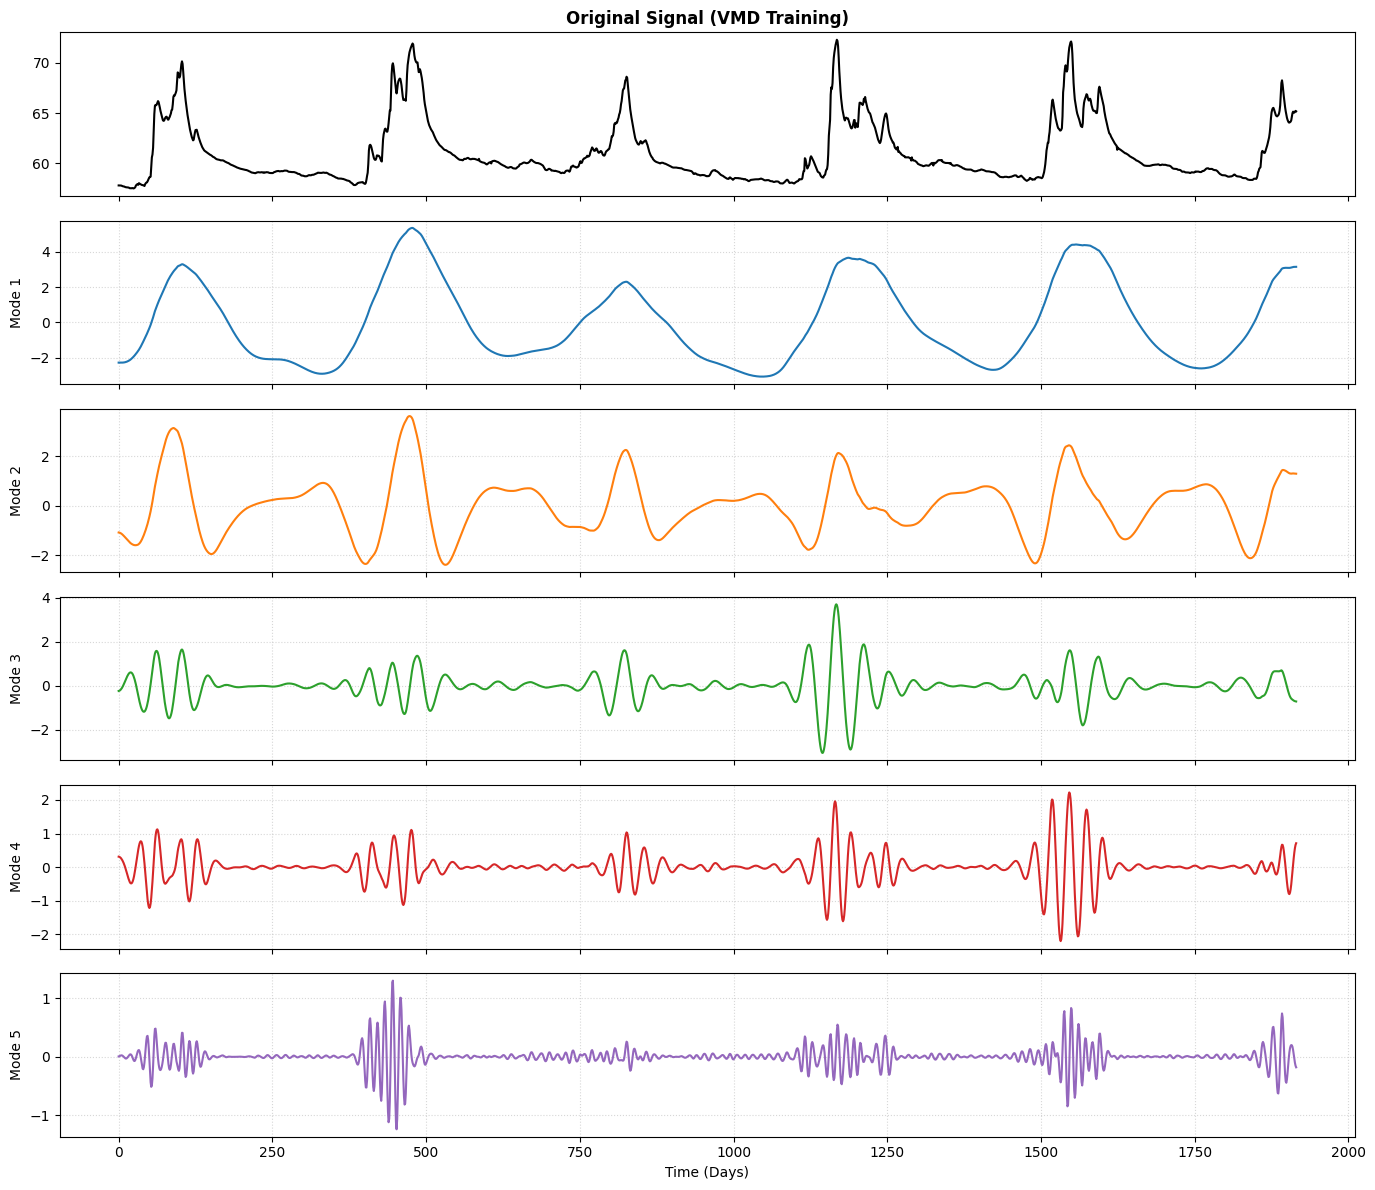

      -> Tuning RFR and XGBoost hyperparameters...
    VMD-RFR: R=0.9693, NSE=0.9222
    VMD-XGB: R=0.9697, NSE=0.9007
    VMD-ANN: R=0.9772, NSE=0.9539
    VMD-LSTM: R=0.9786, NSE=0.9573

  [SSA] Rolling 30-day decomposition...
Plotting SSA IMFs for Training Data...


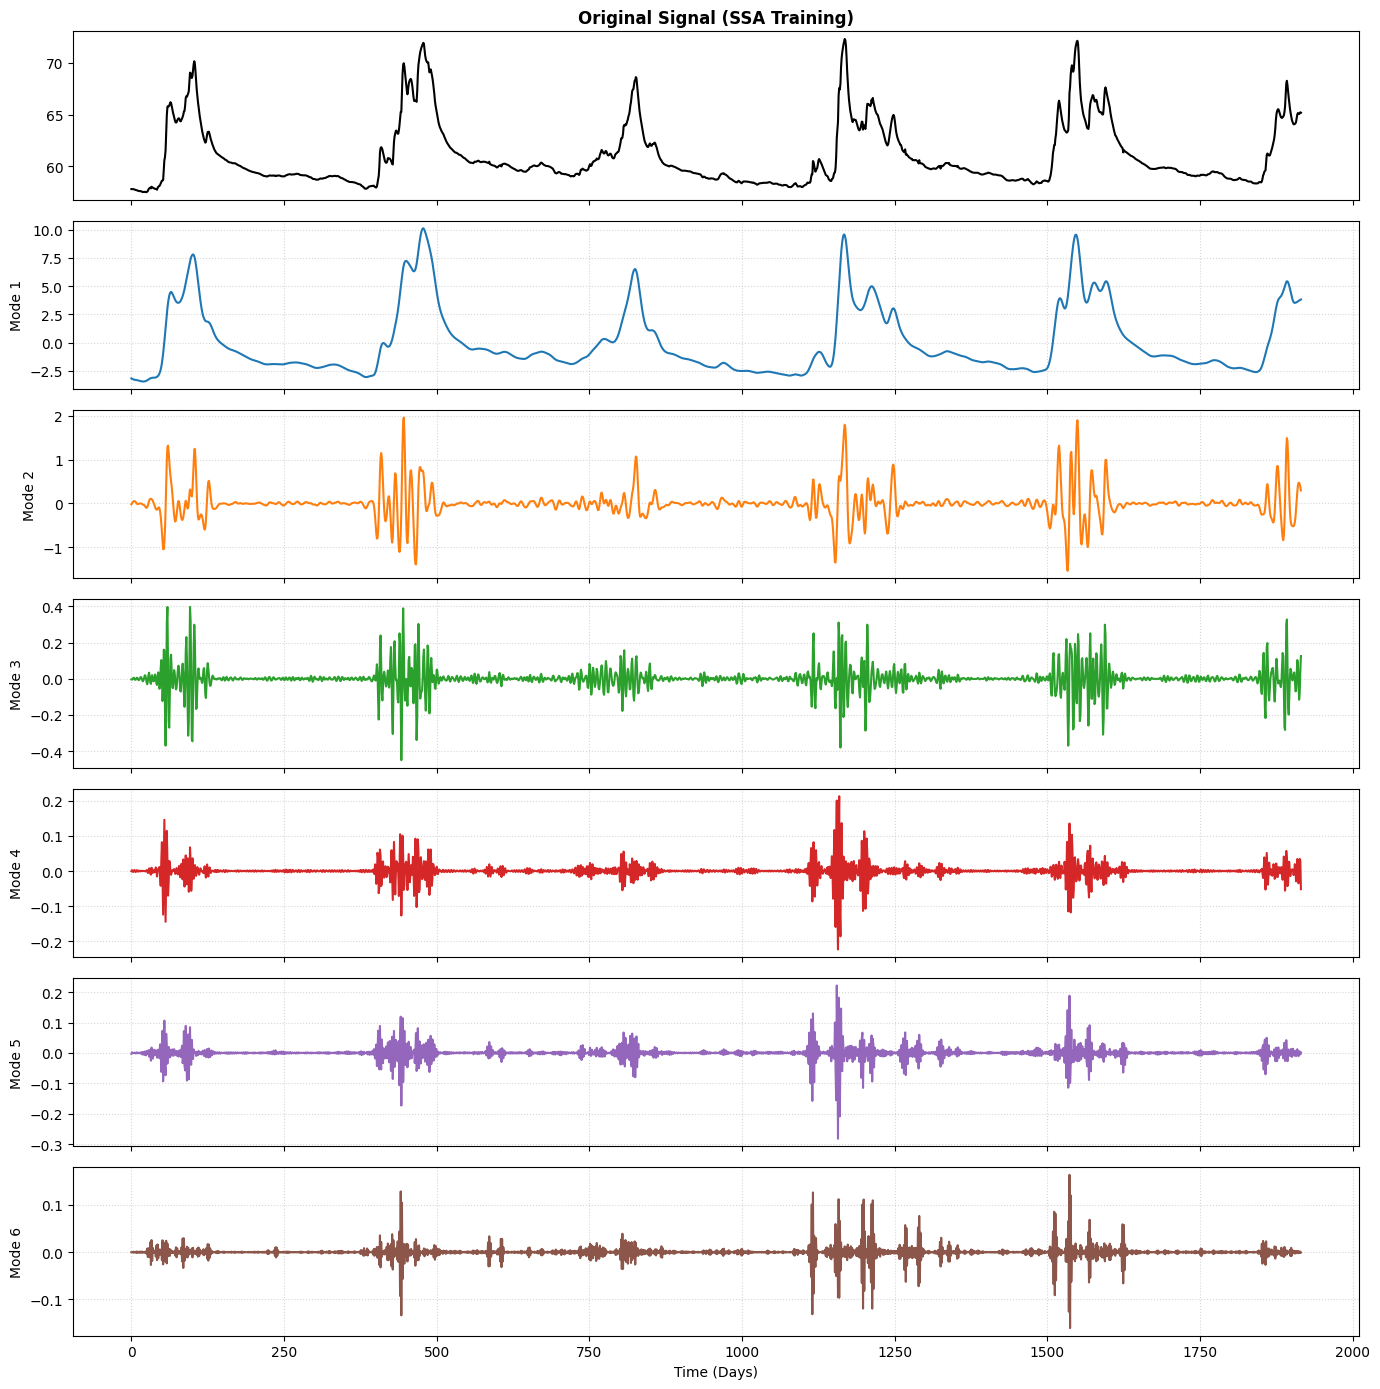

      -> Tuning RFR and XGBoost hyperparameters...
    SSA-RFR: R=0.9530, NSE=0.9051
    SSA-XGB: R=0.9561, NSE=0.9064
    SSA-ANN: R=0.9566, NSE=0.8806
    SSA-LSTM: R=0.9599, NSE=0.8933

  [ENSEMBLE] Ridge Meta-Learner...
    17-Ridge-Ensemble: R=0.9293, NSE=0.8530


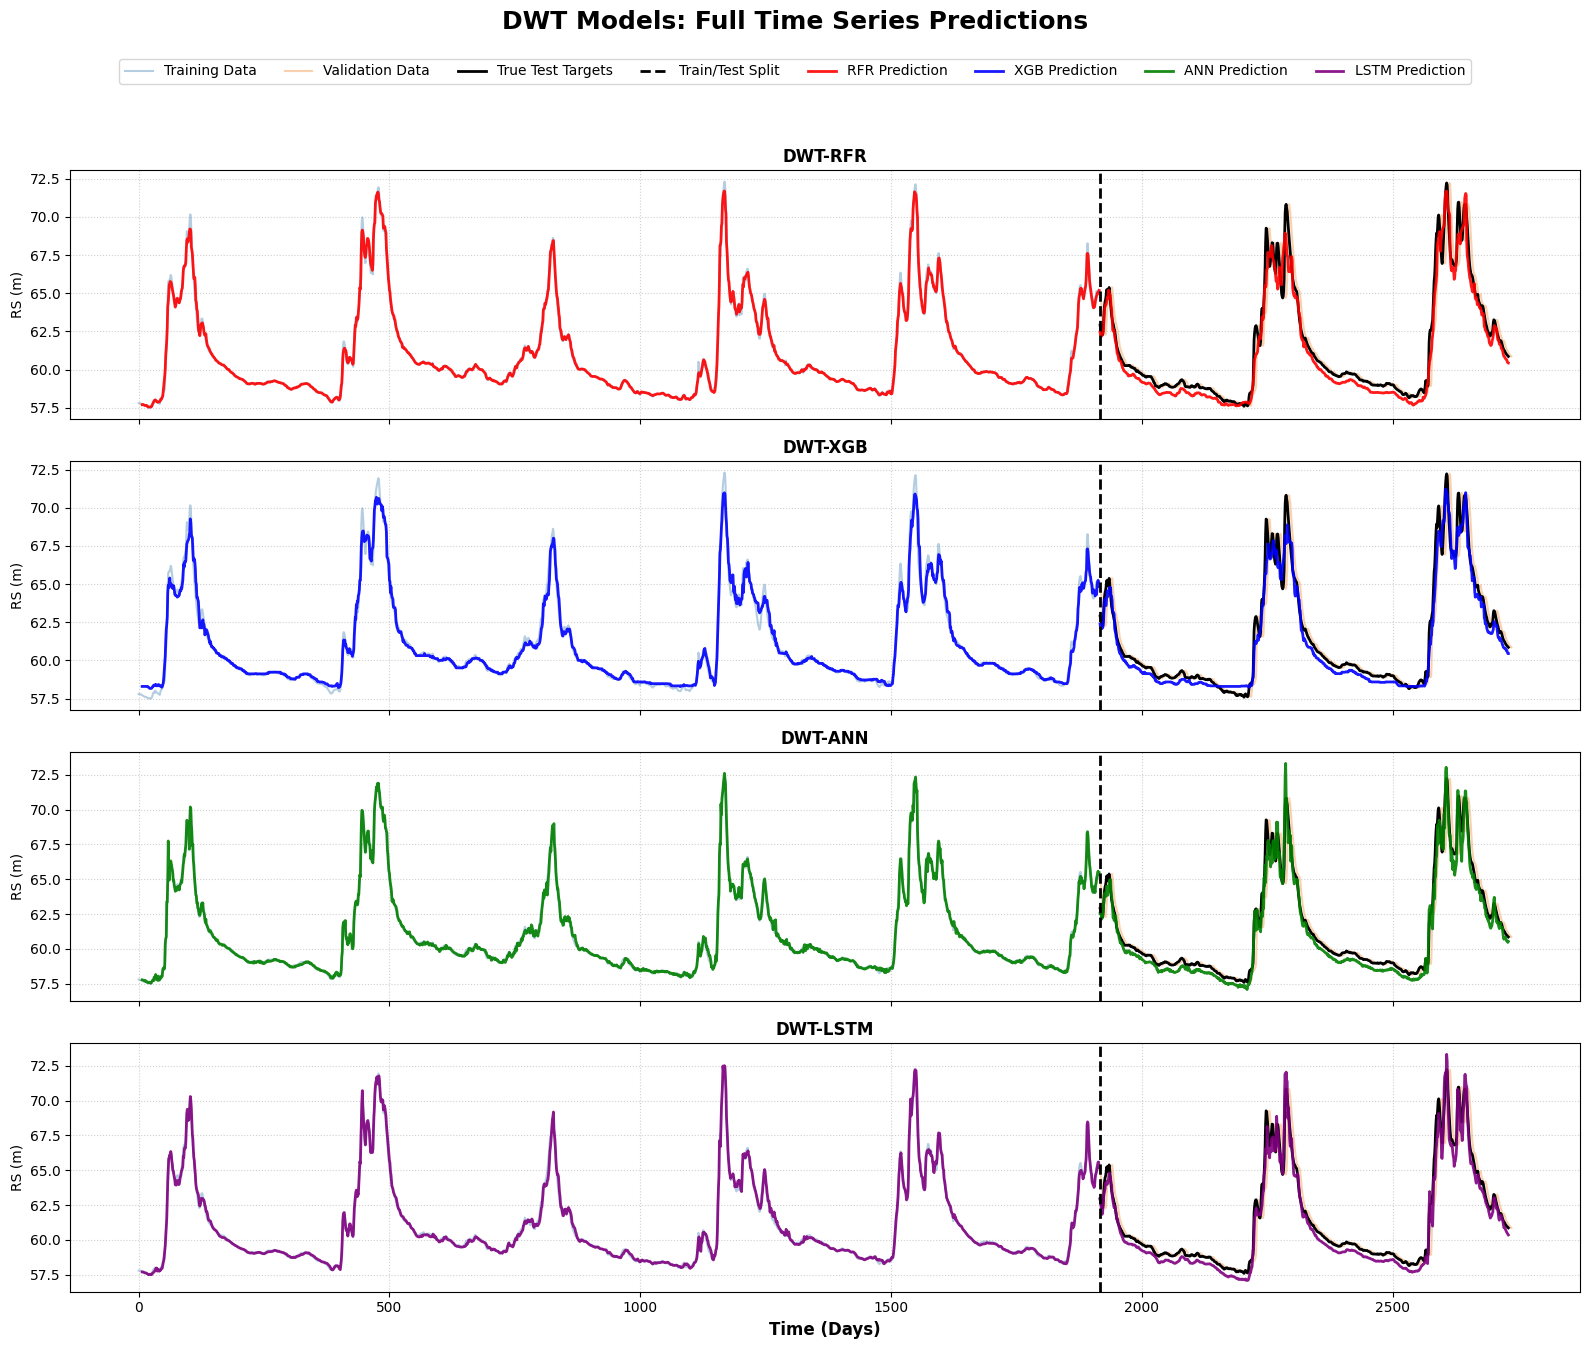

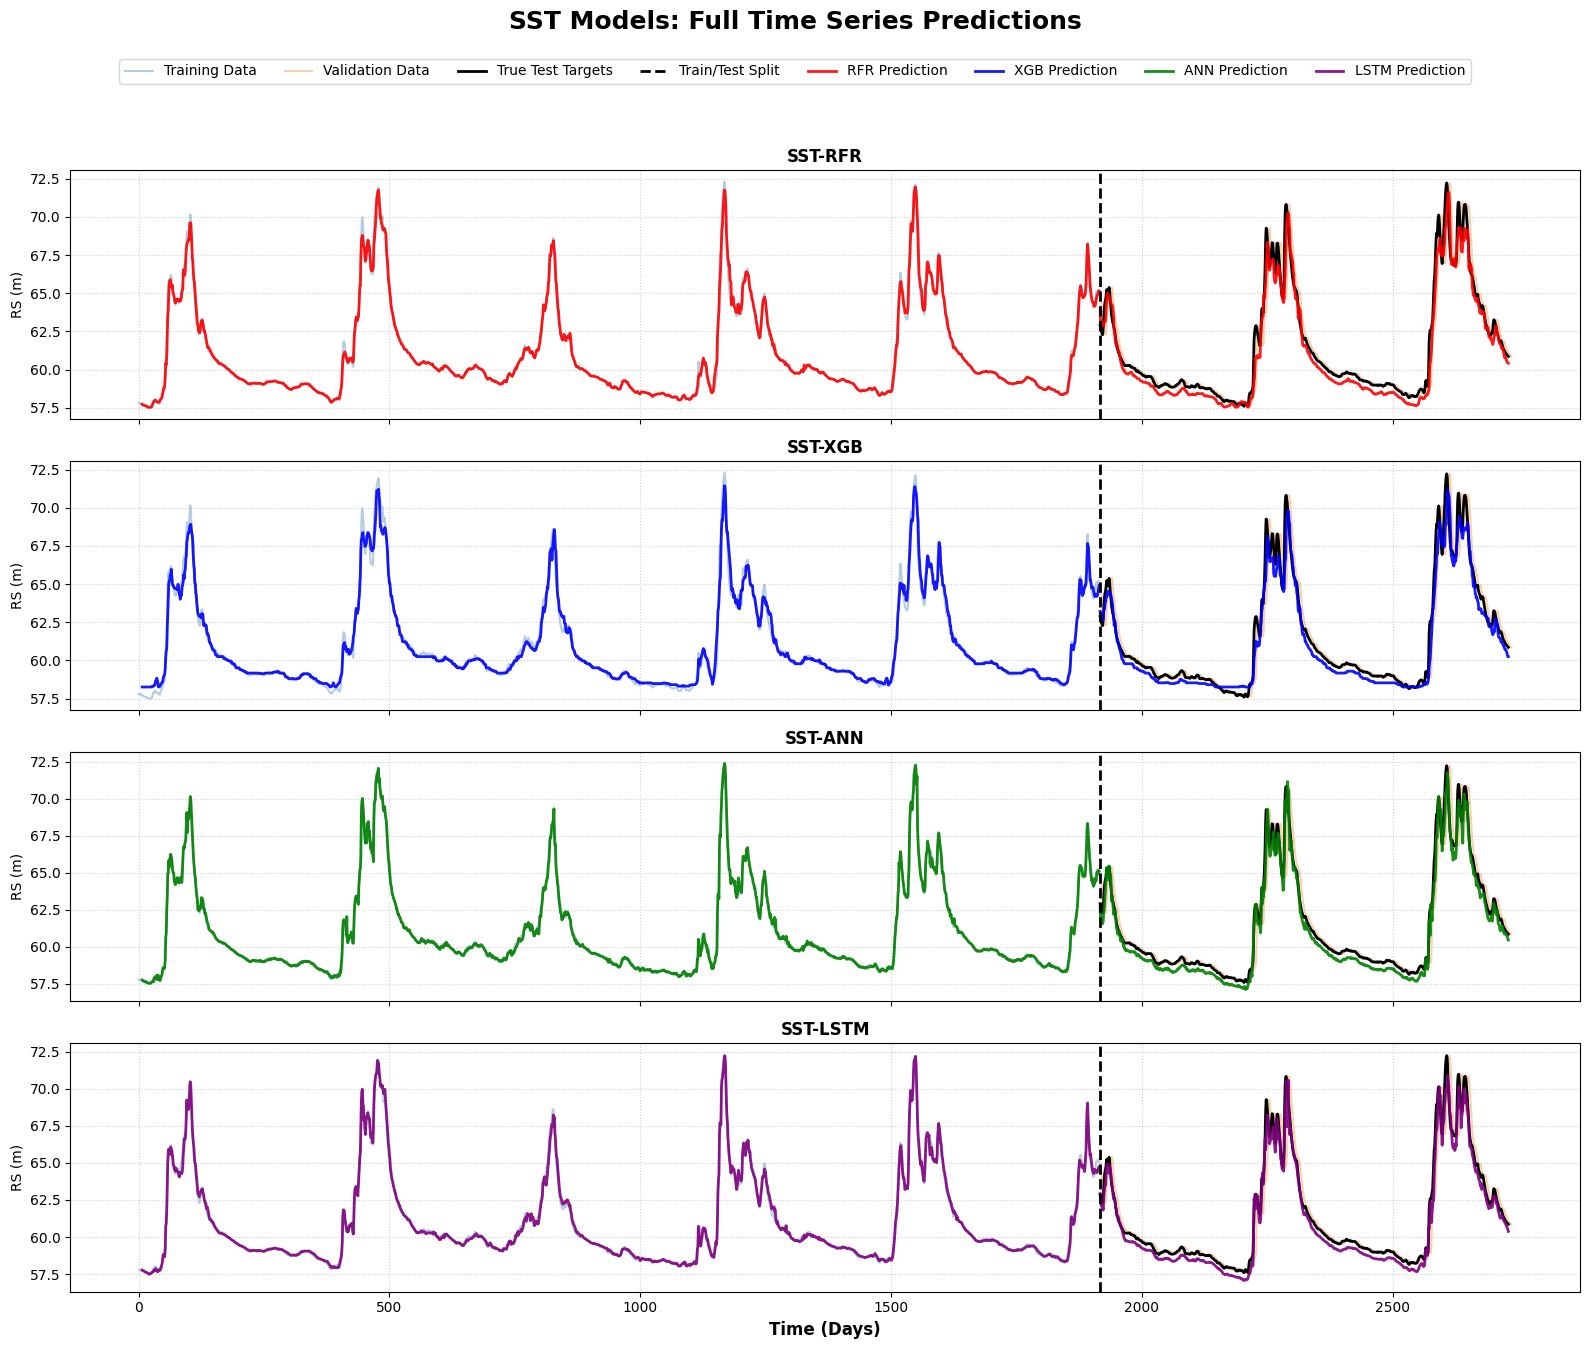

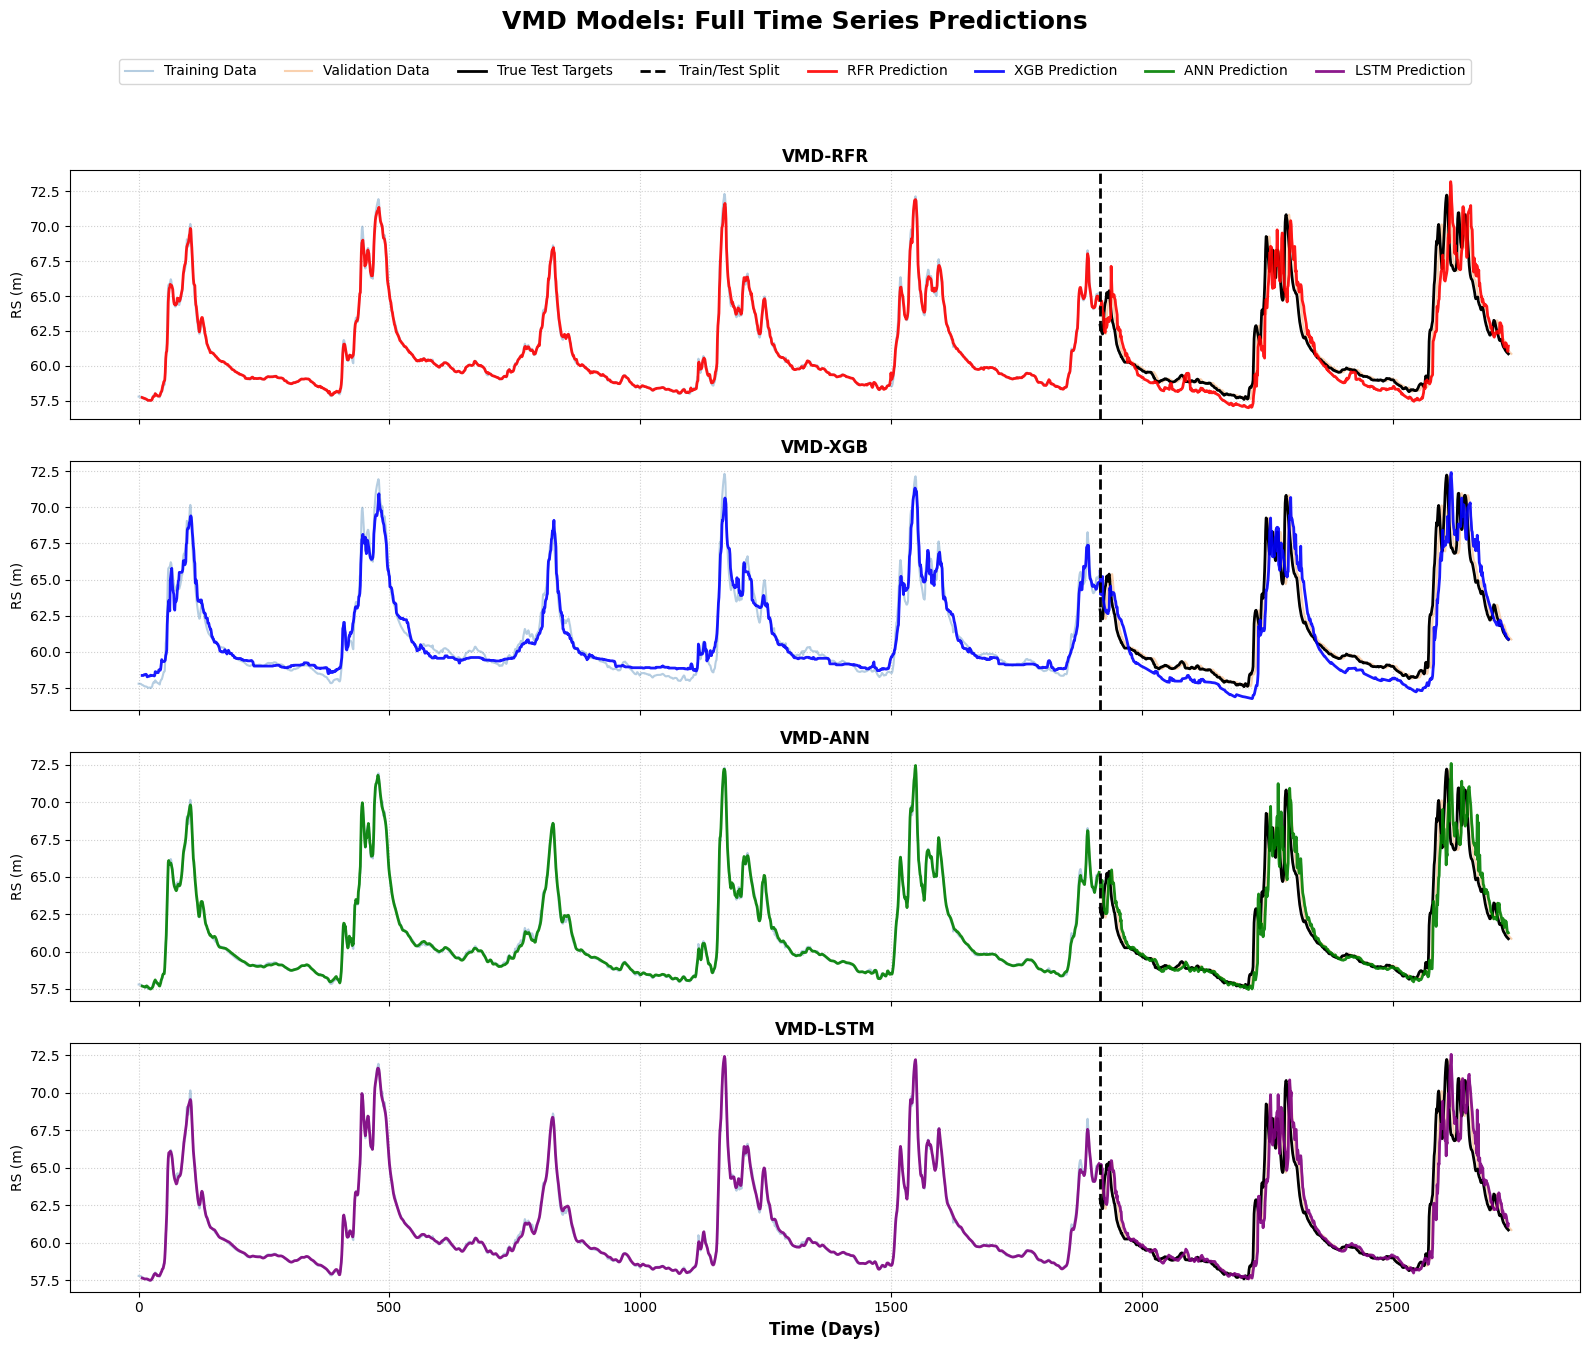

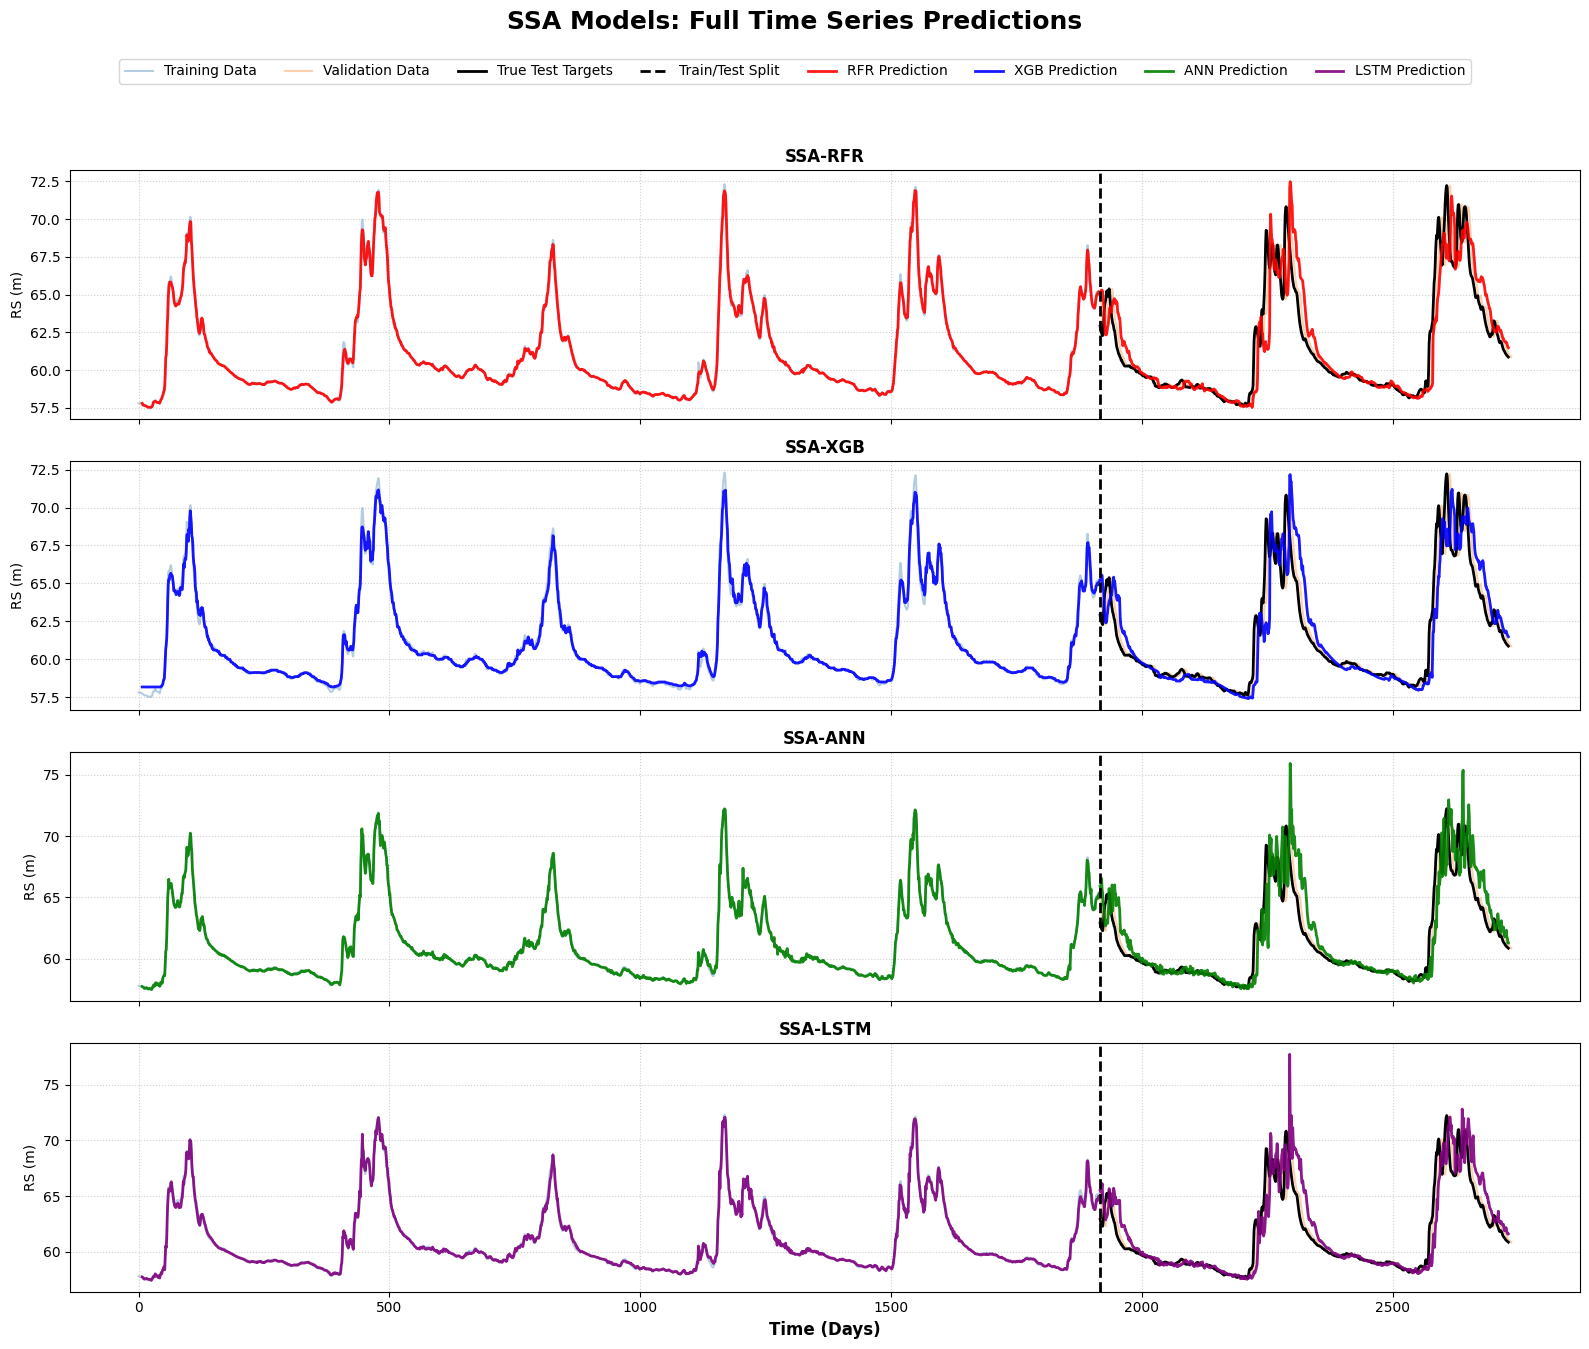

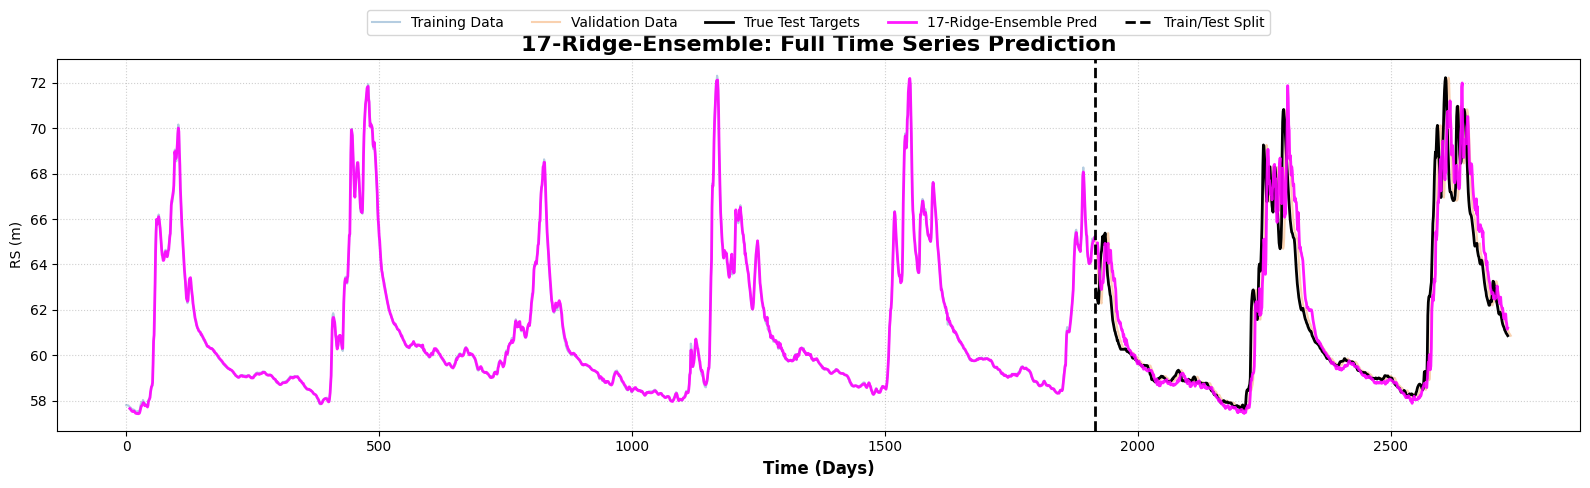

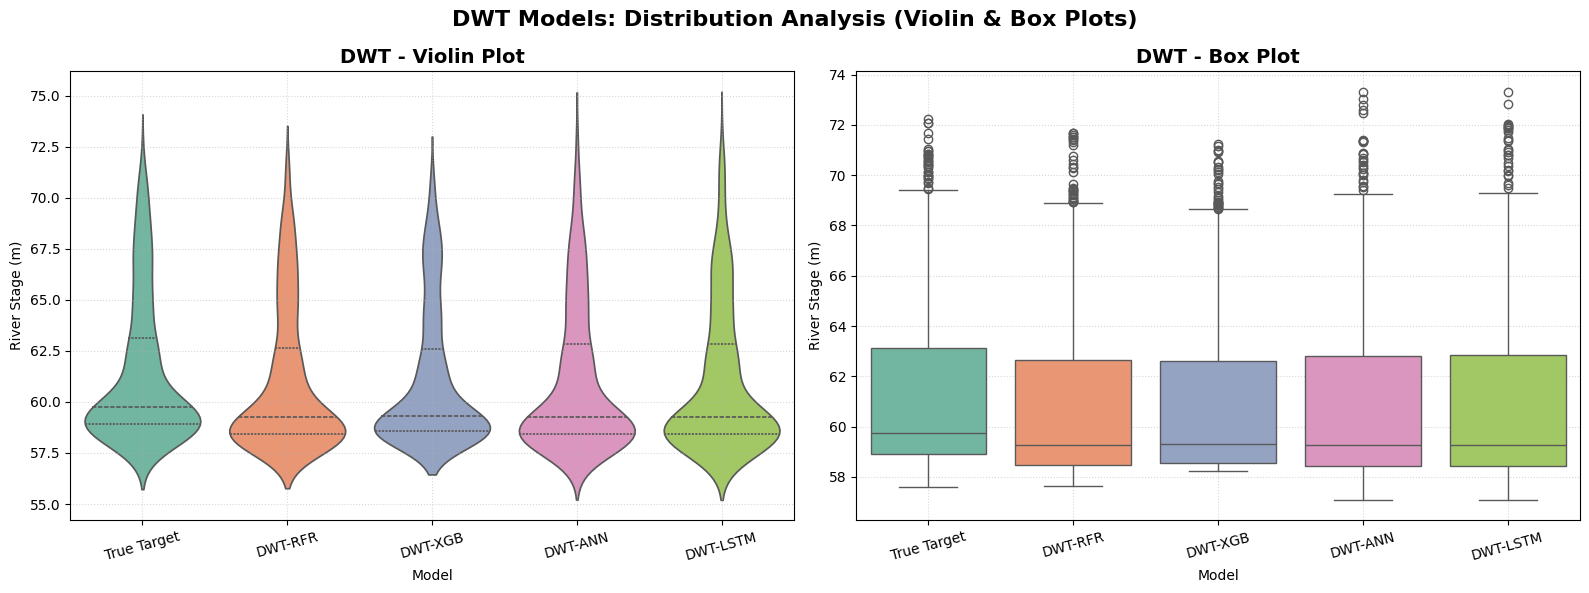

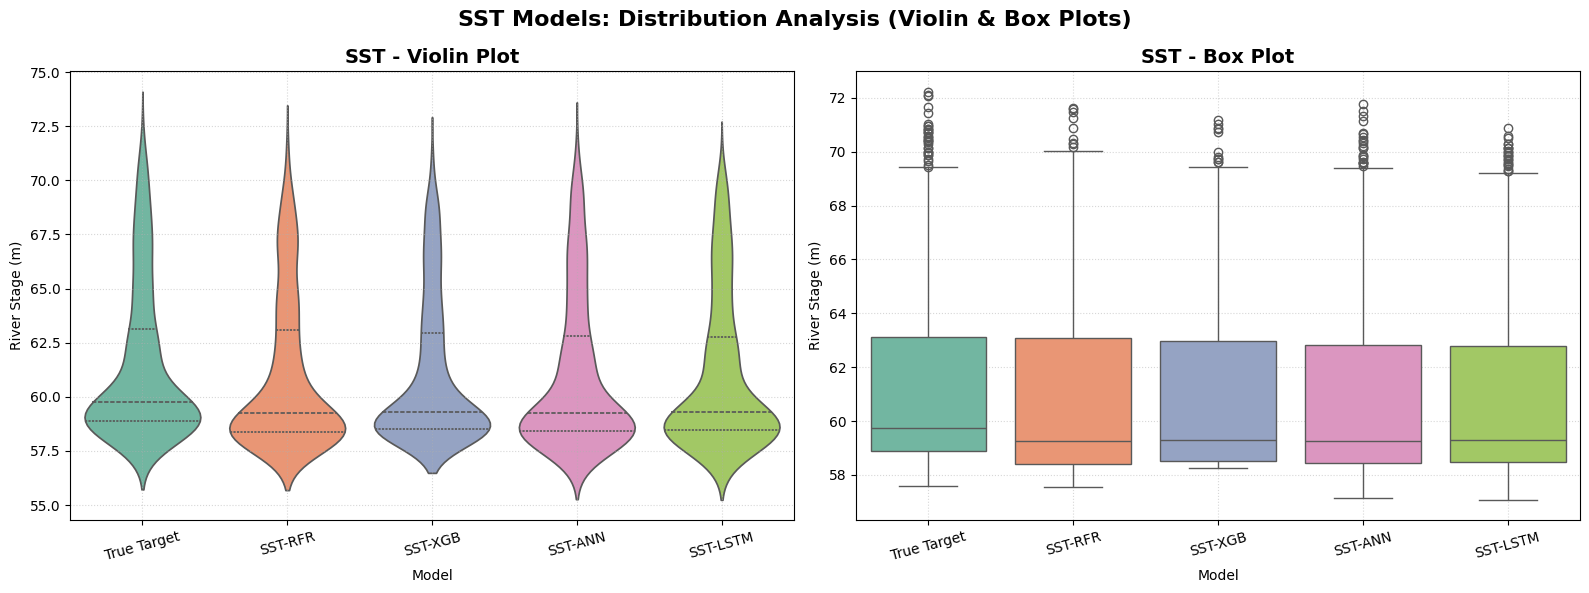

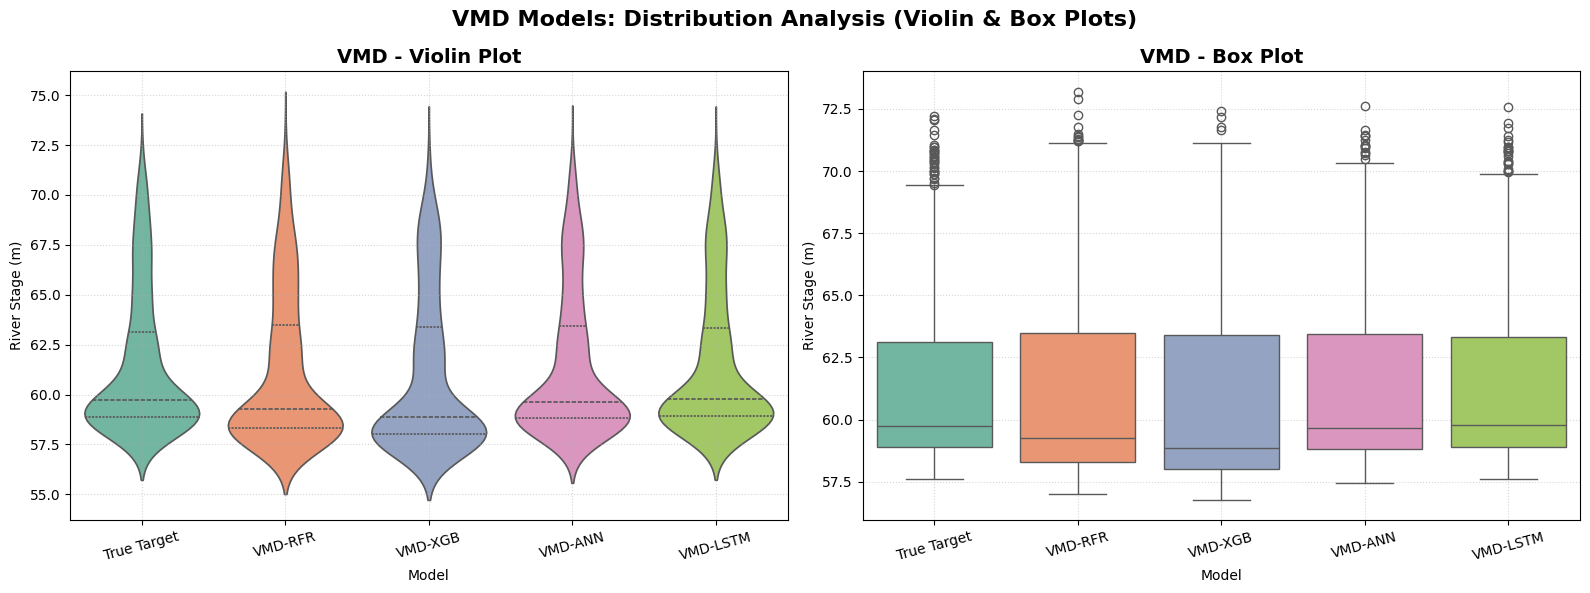

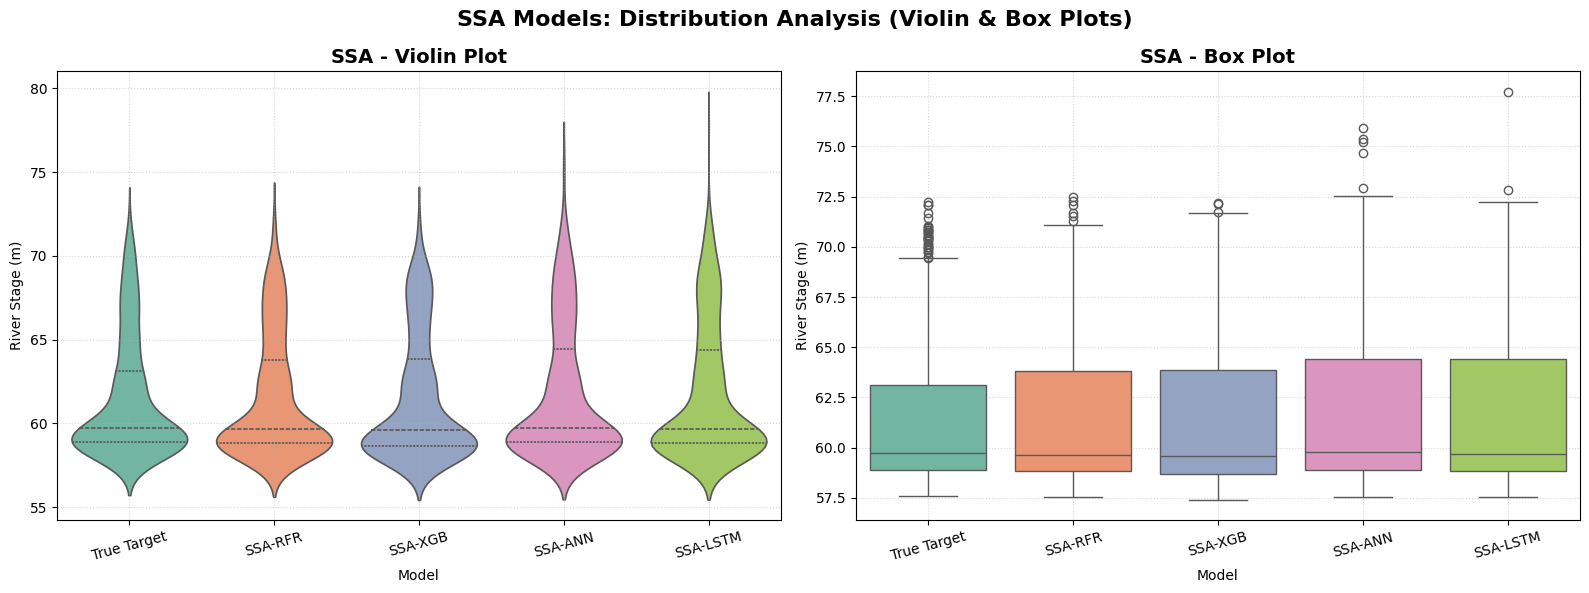

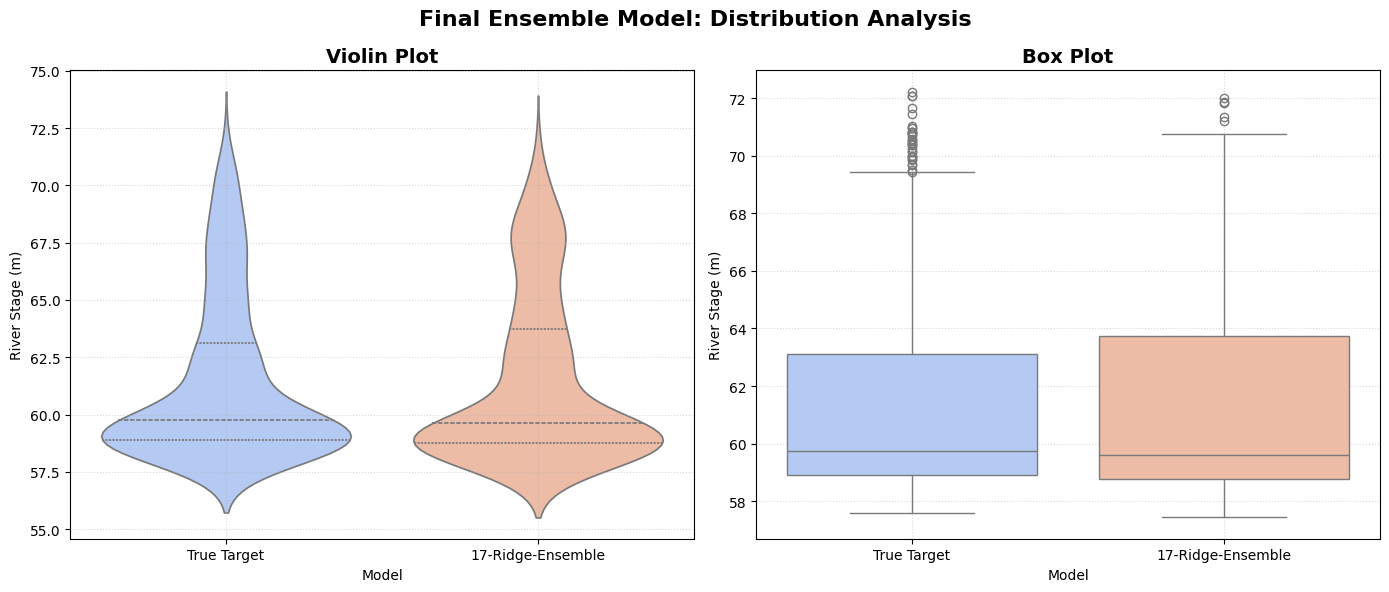

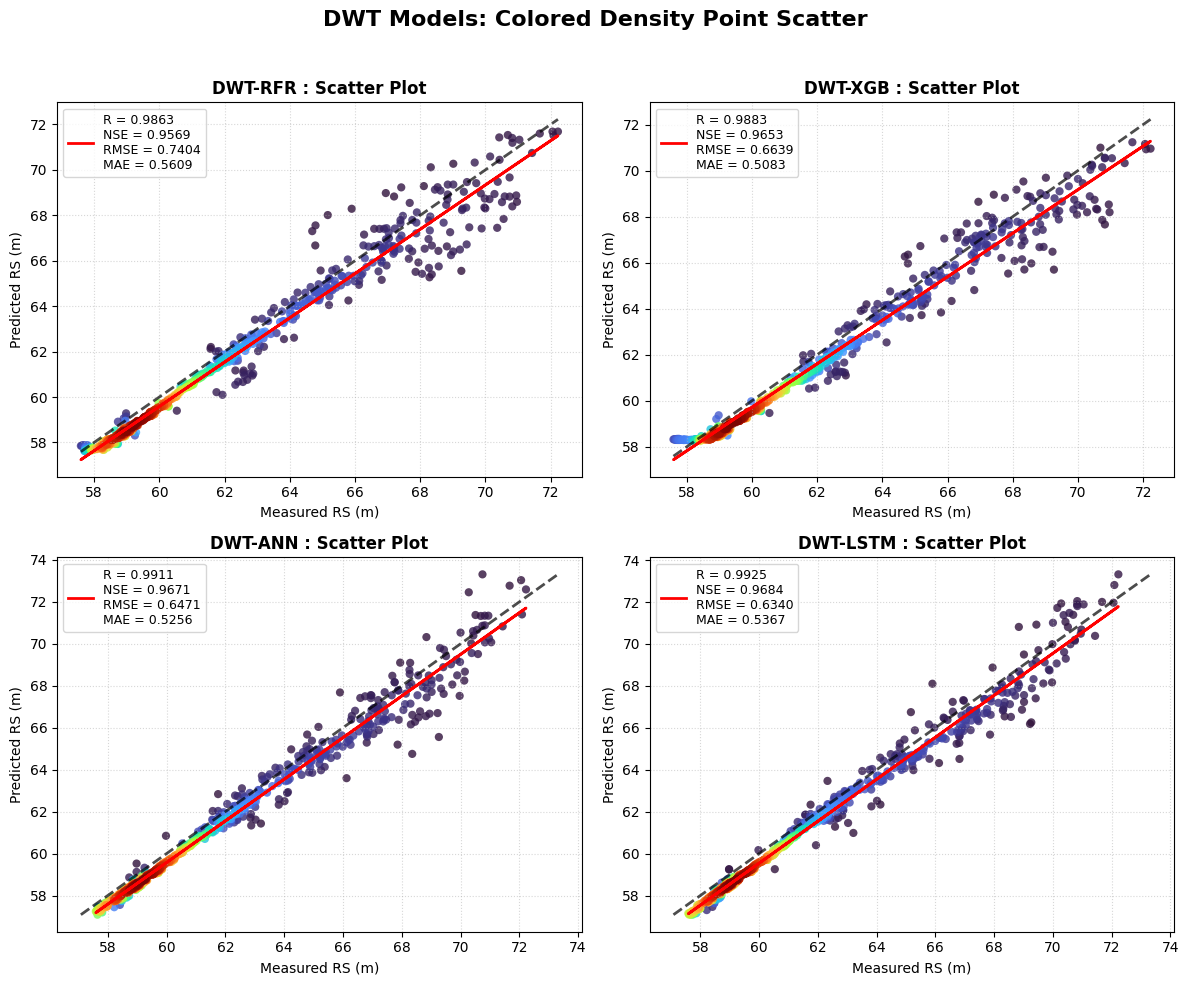

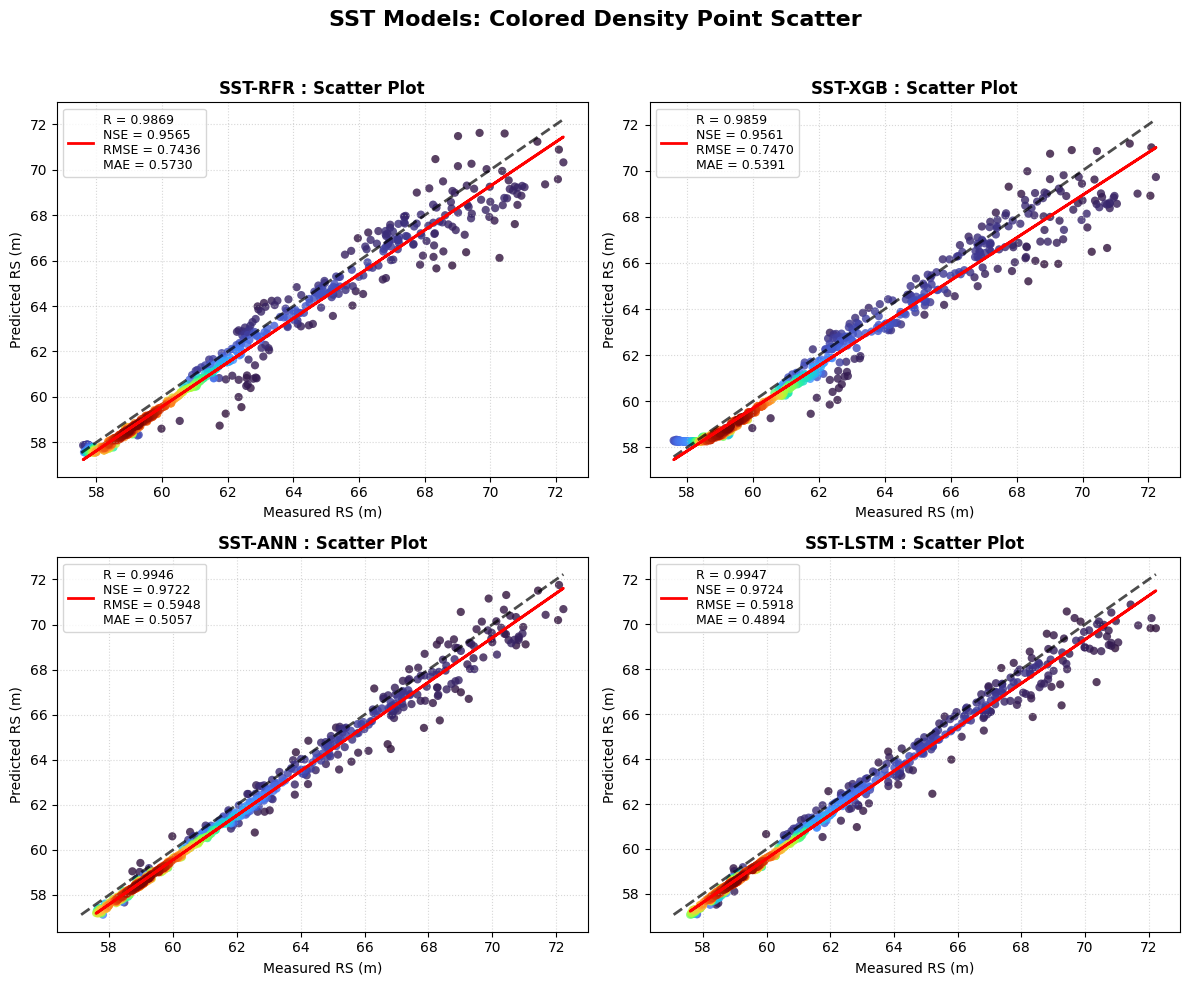

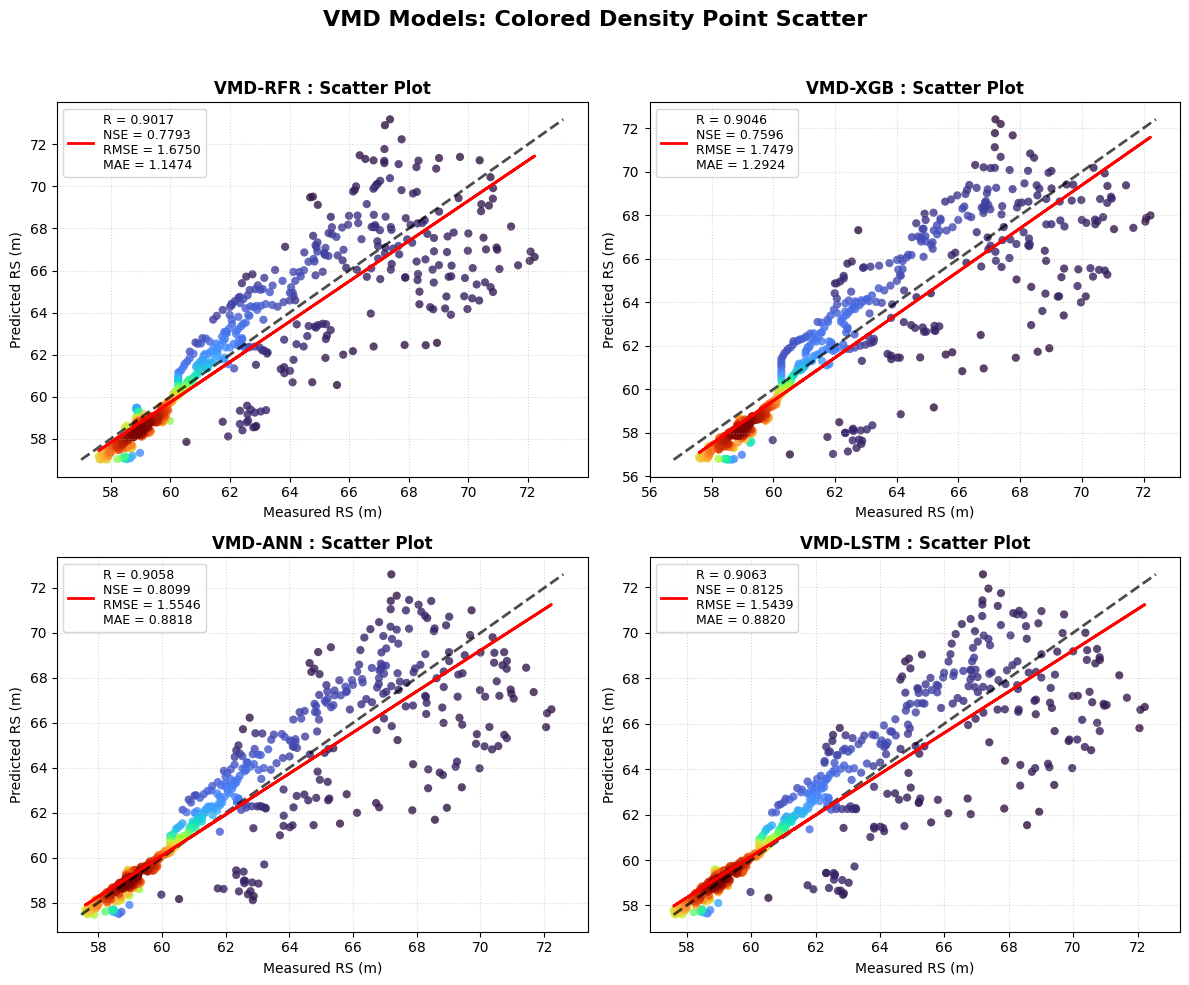

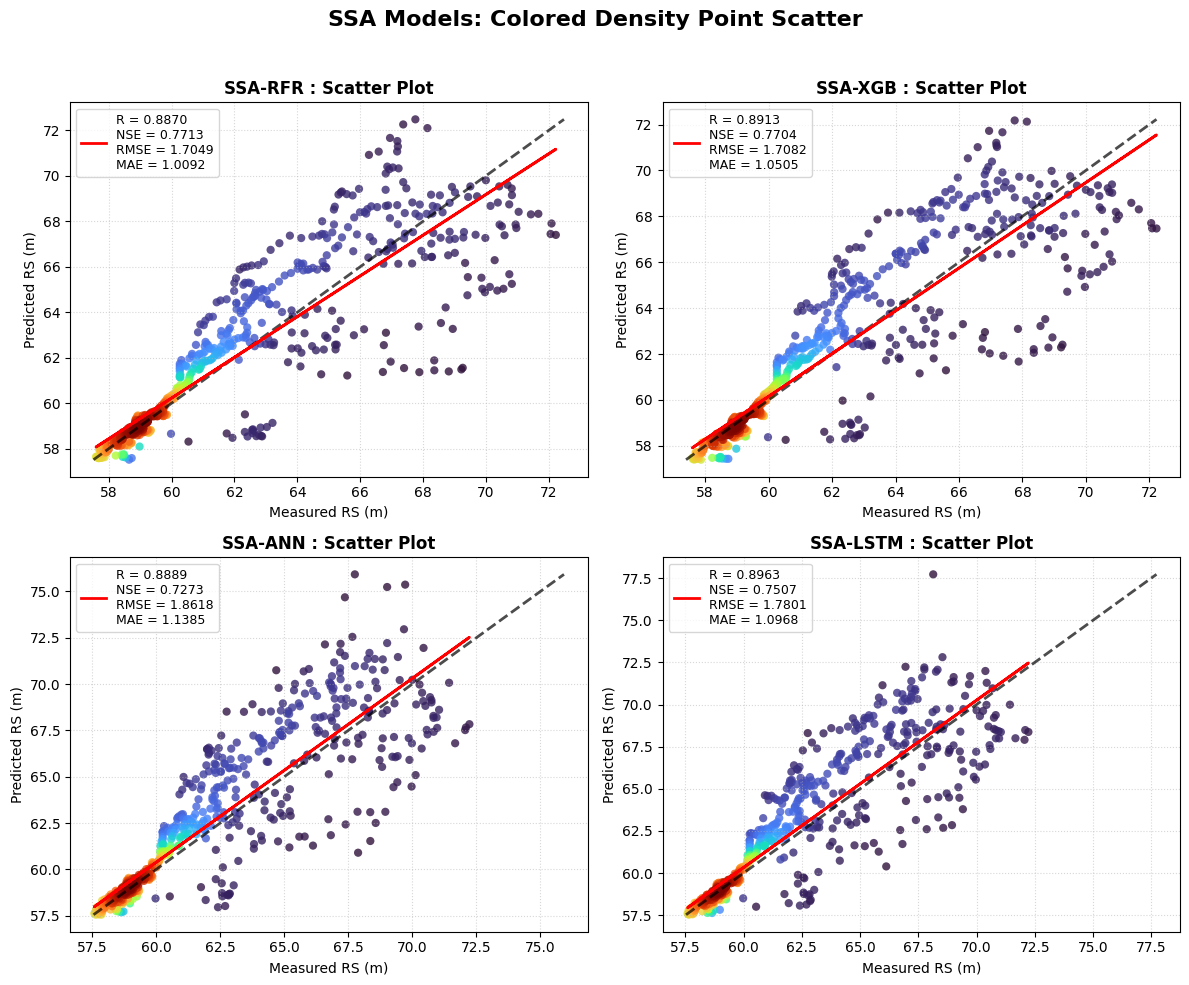

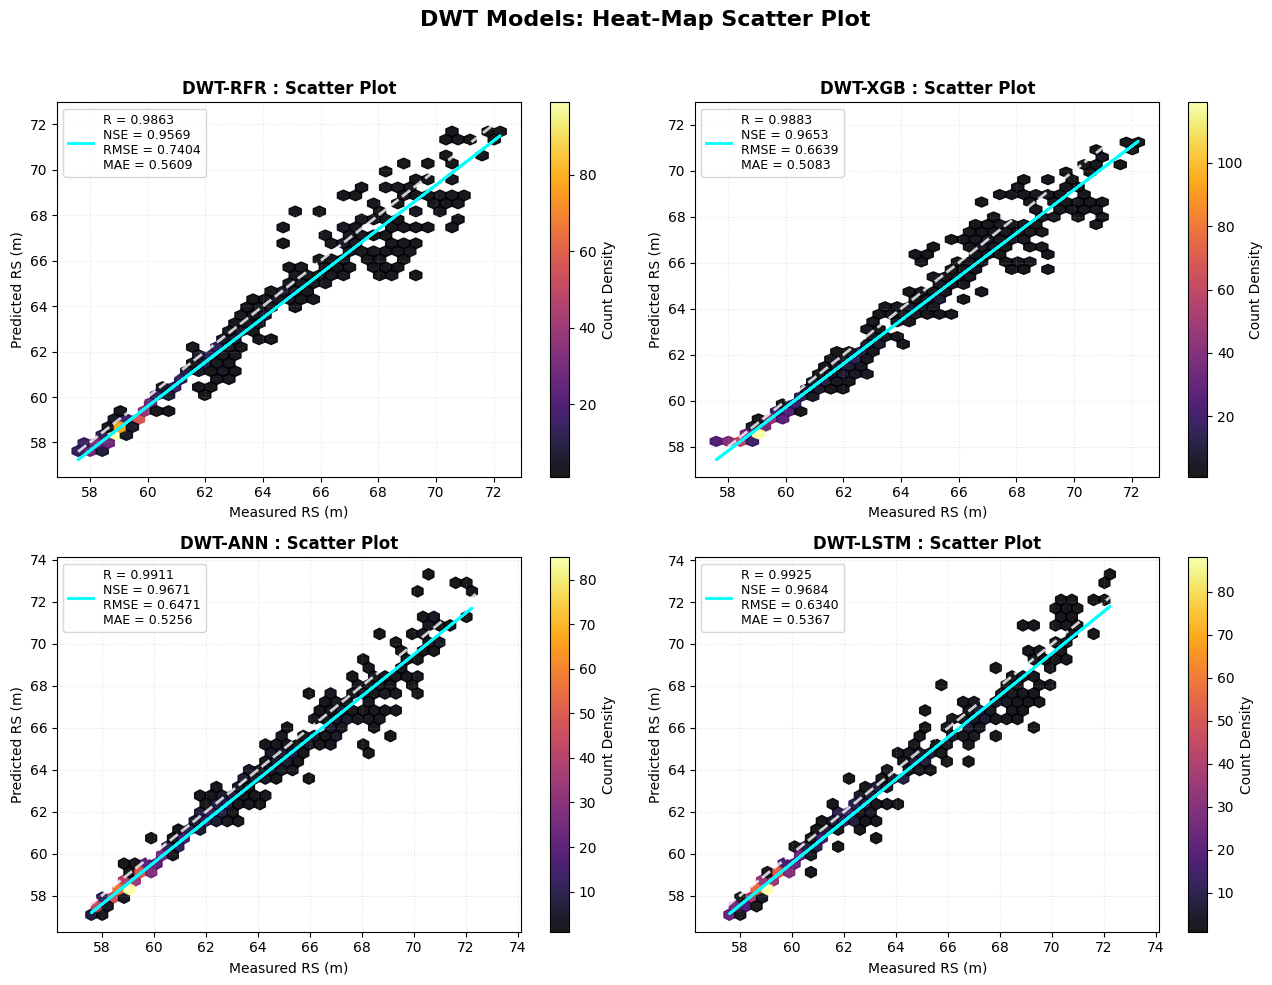

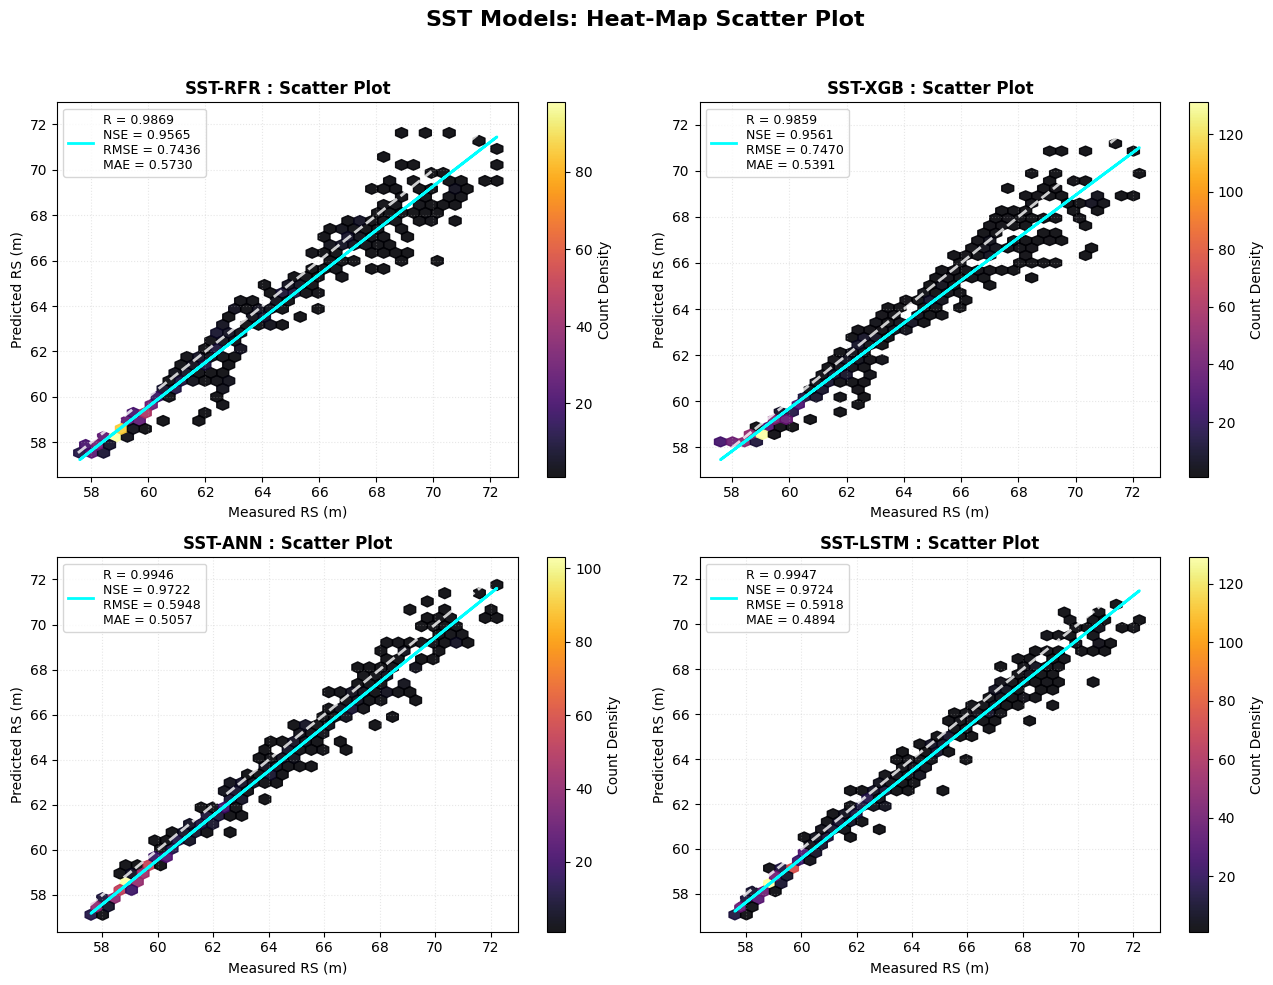

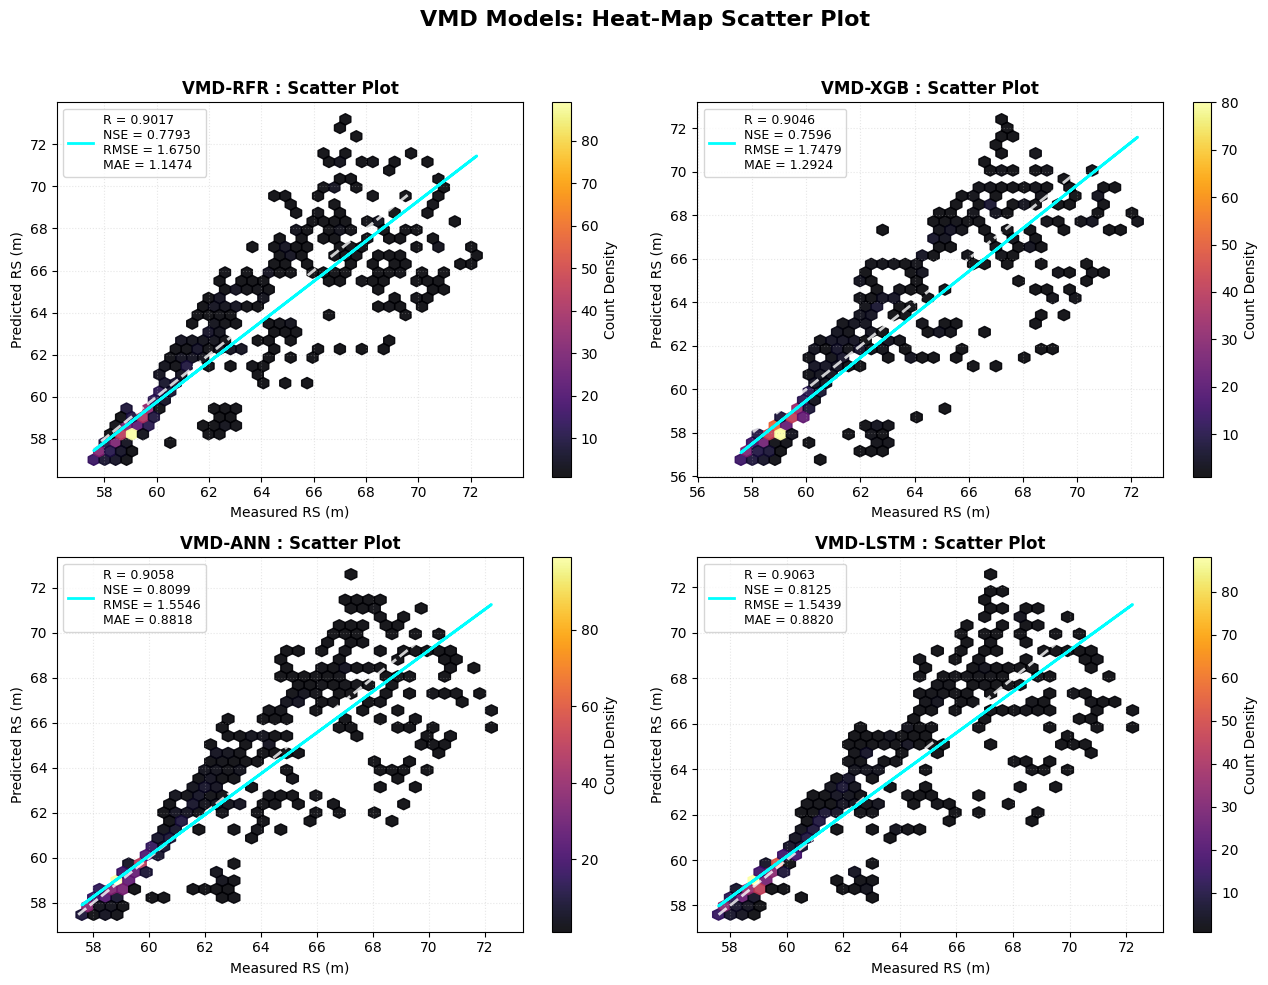

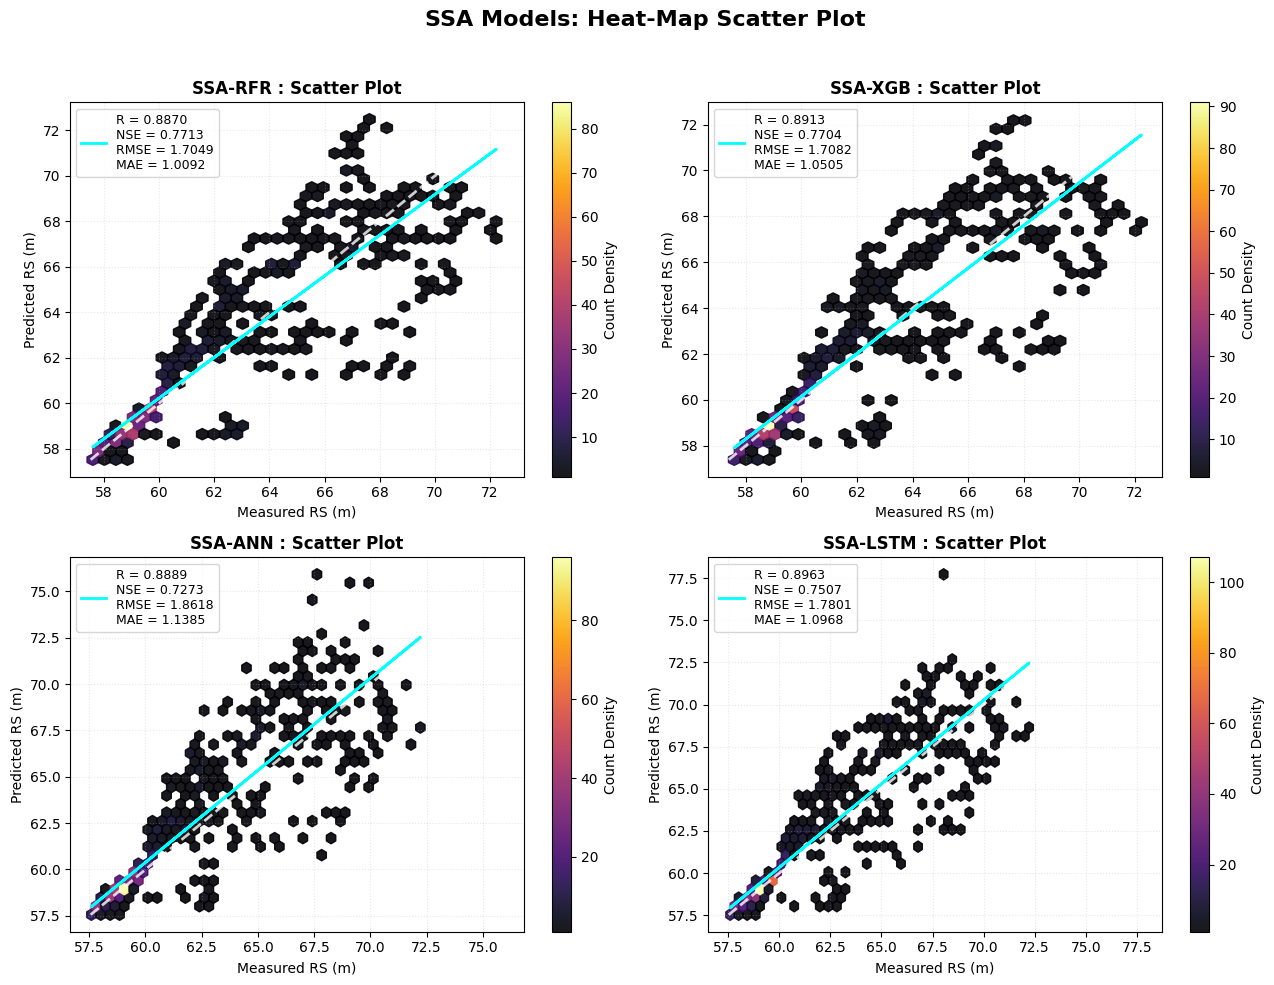


[DONE] FINAL PIPELINE RESULTS


,Horizon,Model,R,NSE,RMSE,MAE
0,t+1,DWT-RFR,0.986349,0.956877,0.740360,0.560899
1,t+1,DWT-XGB,0.988275,0.965320,0.663945,0.508264
2,t+1,DWT-ANN,0.991129,0.967054,0.647133,0.525634
3,t+1,DWT-LSTM,0.992478,0.968377,0.634005,0.536671
4,t+1,SST-RFR,0.986896,0.956499,0.743598,0.572971
5,t+1,SST-XGB,0.985906,0.956095,0.747045,0.539064
6,t+1,SST-ANN,0.994557,0.972164,0.594836,0.505684
7,t+1,SST-LSTM,0.994672,0.972448,0.591785,0.489418
8,t+1,VMD-RFR,0.969329,0.922163,0.993246,0.761225
9,t+1,VMD-XGB,0.969670,0.900653,1.122125,0.937329


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
import warnings
from scipy import stats
from scipy.stats import gaussian_kde
from IPython.display import display

from vmdpy import VMD
from pyts.decomposition import SingularSpectrumAnalysis
import pywt

warnings.filterwarnings("ignore")

LAGS = 6

# ===================== 1. METRICS =====================
def calc_metrics(y_true, y_pred):
    mask = np.isfinite(y_pred) & np.isfinite(y_true)
    yt, yp = y_true[mask], y_pred[mask]
    if len(yt) < 2:
        return np.nan, np.nan, np.nan, np.nan
    r = np.corrcoef(yt, yp)[0, 1] if np.std(yt) > 0 and np.std(yp) > 0 else np.nan
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    den = np.sum((yt - np.mean(yt))**2)
    nse = 1 - np.sum((yp - yt)**2) / den if den > 0 else -99
    return r, nse, rmse, mae

# ===================== 2. DATA CLEANING =====================
def load_and_clean_data(filepath):
    print(f"\nLoading and cleaning data from {filepath}...")
    df = pd.read_csv(filepath)
    df.columns = ["Date", "RS"]
    
    rolling_mean = df["RS"].rolling(window=5, center=True).mean()
    rolling_std = df["RS"].rolling(window=5, center=True).std()
    local_z_score = np.abs((df["RS"] - rolling_mean) / rolling_std)
    
    cleaned_df = pd.DataFrame()
    cleaned_df['Date'] = df['Date']
    cleaned_df["RS"] = df["RS"].mask(local_z_score > 1.5).interpolate(method='linear')
    
    plt.figure(figsize=(16, 5))
    plt.plot(df["RS"], color='red', alpha=0.4, label='Raw Data (With Outliers)')
    plt.plot(cleaned_df["RS"], color='blue', lw=1.5, label='Cleaned Data (Interpolated)')
    plt.title("Whole Dataset: Data Cleaning & Outlier Removal", fontweight='bold')
    plt.ylabel("River Stage (m)")
    plt.xlabel("Days")
    plt.legend()
    plt.grid(linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return cleaned_df["RS"].values

# ===================== 3. DECOMPOSITIONS & PLOTTING =====================
def decomp_vmd(sig):
    c = sig - np.mean(sig)
    if len(c) % 2 != 0:
        c = np.append(c, c[-1])
        u, _, _ = VMD(c, 2000, 0, 5, 0, 1, 1e-7)
        u = u[:, :-1]
    else:
        u, _, _ = VMD(c, 2000, 0, 5, 0, 1, 1e-7)
    return u

def decomp_ssa(sig):
    c = sig - np.mean(sig)
    win = min(10, len(c) // 3)
    return SingularSpectrumAnalysis(window_size=win, groups=6).fit_transform(c.reshape(1, -1))[0]

def decomp_dwt(sig):
    c = sig - np.mean(sig)
    coeffs = pywt.wavedec(c, 'db4', level=4)
    return np.array([pywt.waverec(
        [np.zeros_like(x) if j != i else x for j, x in enumerate(coeffs)], 'db4'
    )[:len(sig)] for i in range(len(coeffs))])

def decomp_sst(sig):
    c = sig - np.mean(sig)
    coeffs = pywt.wavedec(c, 'sym4', level=4)
    return np.array([pywt.waverec(
        [np.zeros_like(x) if j != i else x for j, x in enumerate(coeffs)], 'sym4'
    )[:len(sig)] for i in range(len(coeffs))])

def plot_imfs(sig, imfs, method_name):
    print(f"Plotting {method_name} IMFs for Training Data...")
    n_modes = imfs.shape[0]
    fig, axes = plt.subplots(n_modes + 1, 1, figsize=(14, 2 * (n_modes + 1)), sharex=True)
    axes[0].plot(sig, color='k')
    axes[0].set_title(f"Original Signal ({method_name} Training)", fontweight='bold')
    
    for i in range(n_modes):
        axes[i+1].plot(imfs[i], color=f'C{i}')
        axes[i+1].set_ylabel(f"Mode {i+1}")
        axes[i+1].grid(linestyle=':', alpha=0.5)
    plt.xlabel("Time (Days)")
    plt.tight_layout()
    plt.show()

DECOMP_DETERMINISTIC = {'DWT': decomp_dwt, 'SST': decomp_sst}
DECOMP_LEARNED = {'VMD': decomp_vmd, 'SSA': decomp_ssa}

# ===================== 4. FEATURE BUILDING =====================
def build_lag_xy(imfs, original_sig, mean_val, horizon):
    n_modes, T = imfs.shape
    X, y = [], []
    for t in range(LAGS, T - horizon):
        row = []
        for m in range(n_modes):
            row.extend(imfs[m, t - LAGS:t])
        X.append(row)
        y.append(original_sig[t + horizon] - mean_val)
    return np.array(X), np.array(y)

def build_lag_x_only(imfs):
    n_modes, T = imfs.shape
    X = []
    for t in range(LAGS, T):
        row = []
        for m in range(n_modes):
            row.extend(imfs[m, t - LAGS:t])
        X.append(row)
    return np.array(X)

# ===================== 5. MODEL BUILDERS & TUNING =====================
def tune_tree_models(X_train, y_train):
    print("      -> Tuning RFR and XGBoost hyperparameters...")
    tscv = TimeSeriesSplit(n_splits=3)
    
    rfr_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15, None], 'min_samples_leaf': [2, 4, 6]}
    rfr_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), rfr_param_grid, n_iter=5, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
    rfr_search.fit(X_train, y_train)

    xgb_param_grid = {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [2, 4, 6], 'subsample': [0.7, 0.8, 1.0]}
    xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42), xgb_param_grid, n_iter=5, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
    xgb_search.fit(X_train, y_train)

    return rfr_search.best_estimator_, xgb_search.best_estimator_

def build_lstm(n_features):
    m = Sequential([
        Bidirectional(LSTM(48, activation='relu'), input_shape=(1, n_features)),
        Dense(24, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

# ===================== 6. VISUALIZATION ENGINE =====================

def plot_timeseries_subplots(y_true, meta_train, meta_test, min_len, train_end, test_start_idx, full_sig, h, tr_mean):
    decomps = ['DWT', 'SST', 'VMD', 'SSA']
    models = ['RFR', 'XGB', 'ANN', 'LSTM']
    colors = ['red', 'blue', 'green', 'purple']
    
    train_x = np.arange(0, train_end)
    val_x = np.arange(train_end, len(full_sig))
    test_x = np.arange(test_start_idx, test_start_idx + min_len)
    train_pred_x = np.arange(LAGS + h, train_end) 
    
    for decomp in decomps:
        if f"{decomp}-RFR" not in meta_test: continue
            
        fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
        fig.suptitle(f"{decomp} Models: Full Time Series Predictions", fontsize=18, fontweight='bold', y=0.96)
        
        for idx, mod in enumerate(models):
            ax = axes[idx]
            key = f"{decomp}-{mod}"
            
            ax.plot(train_x, full_sig[:train_end], color='steelblue', lw=1.5, alpha=0.4, label='Training Data' if idx==0 else "")
            ax.plot(val_x, full_sig[train_end:], color='sandybrown', lw=1.5, alpha=0.5, label='Validation Data' if idx==0 else "")
            ax.plot(test_x, y_true[:min_len], color='black', lw=2, label='True Test Targets' if idx==0 else "")
            
            train_pred = meta_train[key] + tr_mean
            train_len = min(len(train_pred_x), len(train_pred))
            
            ax.plot(train_pred_x[:train_len], train_pred[:train_len], color=colors[idx], lw=2, alpha=0.9, label=f'{mod} Prediction')
            ax.plot(test_x, meta_test[key][:min_len], color=colors[idx], lw=2, alpha=0.9)
            
            ax.axvline(x=train_end, color='k', linestyle='--', lw=2, label='Train/Test Split' if idx==0 else "")
            
            ax.set_title(f"{key}", fontweight='bold', fontsize=12)
            ax.set_ylabel("RS (m)")
            ax.grid(linestyle=':', alpha=0.6)
            
        handles, labels = axes[0].get_legend_handles_labels()
        all_handles, all_labels = [], []
        
        for hnd, lbl in zip(handles, labels):
            if lbl in ['Training Data', 'Validation Data', 'True Test Targets', 'Train/Test Split']:
                all_handles.append(hnd)
                all_labels.append(lbl)
                
        for ax in axes:
            hnd, lbl = ax.get_legend_handles_labels()
            for hndr, l in zip(hnd, lbl):
                if 'Prediction' in l:
                    all_handles.append(hndr)
                    all_labels.append(l)
                    
        fig.legend(all_handles, all_labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=8, prop={'size': 10})
            
        plt.xlabel("Time (Days)", fontweight='bold', fontsize=12)
        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.show()

def plot_ensemble_timeseries(y_true, ens_pred_tr, ens_pred_te, min_len, train_end, test_start_idx, full_sig, h):
    train_x = np.arange(0, train_end)
    val_x = np.arange(train_end, len(full_sig))
    test_x = np.arange(test_start_idx, test_start_idx + min_len)
    train_pred_x = np.arange(LAGS + h, train_end) 
    
    plt.figure(figsize=(16, 5))
    
    plt.plot(train_x, full_sig[:train_end], color='steelblue', lw=1.5, alpha=0.4, label='Training Data')
    plt.plot(val_x, full_sig[train_end:], color='sandybrown', lw=1.5, alpha=0.5, label='Validation Data')
    plt.plot(test_x, y_true[:min_len], color='black', lw=2, label='True Test Targets')
    
    train_len = min(len(train_pred_x), len(ens_pred_tr))
    plt.plot(train_pred_x[:train_len], ens_pred_tr[:train_len], color='magenta', lw=2, alpha=0.9, label='17-Ridge-Ensemble Pred')
    plt.plot(test_x, ens_pred_te[:min_len], color='magenta', lw=2, alpha=0.9)
    
    plt.axvline(x=train_end, color='k', linestyle='--', lw=2, label='Train/Test Split')
    plt.title(f"17-Ridge-Ensemble: Full Time Series Prediction", fontweight='bold', fontsize=16)
    plt.ylabel("RS (m)")
    plt.xlabel("Time (Days)", fontweight='bold', fontsize=12)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=5, prop={'size': 10})
    plt.grid(linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- NEW: Violin & Box Plot Generation by Decomposition ---
def plot_violin_box_by_decomp(y_true, meta_test, min_len):
    decomps = ['DWT', 'SST', 'VMD', 'SSA']
    models = ['RFR', 'XGB', 'ANN', 'LSTM']
    
    for decomp in decomps:
        if f"{decomp}-RFR" not in meta_test: continue
        
        # Build dictionary of true targets vs model predictions for this decomp
        plot_dict = {'True Target': y_true[:min_len]}
        for mod in models:
            key = f"{decomp}-{mod}"
            plot_dict[key] = meta_test[key][:min_len]
            
        plot_df = pd.DataFrame(plot_dict)
        melted_df = plot_df.melt(var_name='Model', value_name='River Stage (m)')
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f"{decomp} Models: Distribution Analysis (Violin & Box Plots)", fontsize=16, fontweight='bold')
        
        # Violin Plot
        sns.violinplot(data=melted_df, x='Model', y='River Stage (m)', ax=axes[0], palette='Set2', inner='quartile')
        axes[0].set_title(f"{decomp} - Violin Plot", fontweight='bold', fontsize=14)
        axes[0].tick_params(axis='x', rotation=15)
        axes[0].grid(linestyle=':', alpha=0.5)
        
        # Box Plot
        sns.boxplot(data=melted_df, x='Model', y='River Stage (m)', ax=axes[1], palette='Set2')
        axes[1].set_title(f"{decomp} - Box Plot", fontweight='bold', fontsize=14)
        axes[1].tick_params(axis='x', rotation=15)
        axes[1].grid(linestyle=':', alpha=0.5)
        
        plt.tight_layout()
        plt.show()

def plot_ensemble_violin_box(y_true, ens_pred, min_len):
    """ Standalone Violin and Box plot for the final Ensemble model """
    plot_dict = {
        'True Target': y_true[:min_len],
        '17-Ridge-Ensemble': ens_pred[:min_len]
    }
    plot_df = pd.DataFrame(plot_dict)
    melted_df = plot_df.melt(var_name='Model', value_name='River Stage (m)')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Final Ensemble Model: Distribution Analysis", fontsize=16, fontweight='bold')
    
    sns.violinplot(data=melted_df, x='Model', y='River Stage (m)', ax=axes[0], palette='coolwarm', inner='quartile')
    axes[0].set_title("Violin Plot", fontweight='bold', fontsize=14)
    axes[0].grid(linestyle=':', alpha=0.5)
    
    sns.boxplot(data=melted_df, x='Model', y='River Stage (m)', ax=axes[1], palette='coolwarm')
    axes[1].set_title("Box Plot", fontweight='bold', fontsize=14)
    axes[1].grid(linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
# --------------------------------------------------------

def plot_density_scatter_grids(y_true, meta_test, min_len):
    decomps = ['DWT', 'SST', 'VMD', 'SSA']
    models = ['RFR', 'XGB', 'ANN', 'LSTM']
    
    for decomp in decomps:
        if f"{decomp}-RFR" not in meta_test: continue
            
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle(f"{decomp} Models: Colored Density Point Scatter", fontsize=16, fontweight='bold')
        axes = axes.flatten()
        
        for idx, mod in enumerate(models):
            key = f"{decomp}-{mod}"
            y_pred = meta_test[key][:min_len]
            ax = axes[idx]
            
            xy = np.vstack([y_true, y_pred])
            try:
                z = gaussian_kde(xy)(xy)
                sort_idx = z.argsort()
                yt_s, yp_s, z_s = y_true[sort_idx], y_pred[sort_idx], z[sort_idx]
                ax.scatter(yt_s, yp_s, c=z_s, s=35, cmap='turbo', edgecolor='none', alpha=0.8)
            except:
                ax.scatter(y_true, y_pred, alpha=0.5, color='teal')
            
            min_v, max_v = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
            ax.plot([min_v, max_v], [min_v, max_v], 'k--', lw=2, alpha=0.7)
            
            r, nse, rmse, mae = calc_metrics(y_true, y_pred)
            slope, intercept, _, _, _ = stats.linregress(y_true, y_pred)
            
            metrics_label = f"R = {r:.4f}\nNSE = {nse:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}"
            ax.plot(y_true, intercept + slope*y_true, 'r-', lw=2, label=metrics_label)
            
            ax.set_title(f"{key} : Scatter Plot", fontweight='bold', fontsize=12)
            ax.set_xlabel("Measured RS (m)")
            ax.set_ylabel("Predicted RS (m)")
            
            ax.legend(loc='upper left', prop={'size': 9})
            ax.grid(linestyle=':', alpha=0.5)
            
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

def plot_heatmap_scatter_grids(y_true, meta_test, min_len):
    decomps = ['DWT', 'SST', 'VMD', 'SSA']
    models = ['RFR', 'XGB', 'ANN', 'LSTM']
    
    for decomp in decomps:
        if f"{decomp}-RFR" not in meta_test: continue
            
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        fig.suptitle(f"{decomp} Models: Heat-Map Scatter Plot", fontsize=16, fontweight='bold')
        axes = axes.flatten()
        
        for idx, mod in enumerate(models):
            key = f"{decomp}-{mod}"
            y_pred = meta_test[key][:min_len]
            ax = axes[idx]
            
            hb = ax.hexbin(y_true, y_pred, gridsize=35, cmap='inferno', mincnt=1, alpha=0.9)
            cb = fig.colorbar(hb, ax=ax)
            cb.set_label('Count Density')
            
            min_v, max_v = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
            ax.plot([min_v, max_v], [min_v, max_v], color='white', linestyle='--', lw=2, alpha=0.8)
            
            r, nse, rmse, mae = calc_metrics(y_true, y_pred)
            slope, intercept, _, _, _ = stats.linregress(y_true, y_pred)
            
            metrics_label = f"R = {r:.4f}\nNSE = {nse:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}"
            ax.plot(y_true, intercept + slope*y_true, color='cyan', lw=2, label=metrics_label)
            
            ax.set_title(f"{key} : Scatter Plot", fontweight='bold', fontsize=12)
            ax.set_xlabel("Measured RS (m)")
            ax.set_ylabel("Predicted RS (m)")
            
            ax.legend(loc='upper left', prop={'size': 9})
            ax.grid(linestyle=':', alpha=0.3)
            
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# ===================== 7. MAIN PIPELINE =====================
def run_pipeline(h_list=[1]):
    FILE_PATH = "CWC_VARANASI_WSE_DailyMean.csv" 
    
    full_sig = load_and_clean_data(FILE_PATH)
    
    split_idx = int(len(full_sig) * 0.70)
    train_sig = full_sig[:split_idx]
    test_sig = full_sig[split_idx:]
    tr_mean = np.mean(train_sig)
    train_end = len(train_sig)

    all_metrics = []

    for h in h_list:
        print(f"\n{'='*60}\n  HORIZON: t+{h} Days\n{'='*60}")
        meta_train, meta_test = {}, {}
        meta_y_tr = None

        # --- A) DETERMINISTIC DECOMPOSITIONS ---
        for dname, dfunc in DECOMP_DETERMINISTIC.items():
            print(f"\n  [{dname}] Full-length decomposition...")
            tr_imfs = dfunc(train_sig)
            
            if h == h_list[0]:
                plot_imfs(train_sig, tr_imfs, dname)
                
            X_tr, y_tr = build_lag_xy(tr_imfs, train_sig, tr_mean, h)
            if meta_y_tr is None: meta_y_tr = y_tr.copy()

            te_imfs = dfunc(test_sig)
            X_te_all = build_lag_x_only(te_imfs)
            max_te = len(test_sig) - LAGS - h
            X_te = X_te_all[:max_te]
            y_te_true = test_sig[LAGS + h : LAGS + h + max_te]

            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            best_rfr, best_xgb = tune_tree_models(X_tr_s, y_tr)
            fixed_ann = MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.01, max_iter=200, early_stopping=True, validation_fraction=0.15, random_state=42)
            
            models = {'RFR': best_rfr, 'XGB': best_xgb, 'ANN': fixed_ann}

            for mname, model in models.items():
                key = f"{dname}-{mname}"
                model.fit(X_tr_s, y_tr)
                meta_train[key] = model.predict(X_tr_s)
                preds_te = model.predict(X_te_s) + tr_mean
                meta_test[key] = preds_te
                
                r, nse, rmse, mae = calc_metrics(y_te_true, preds_te)
                all_metrics.append({'Horizon': f't+{h}', 'Model': key, 'R': r, 'NSE': nse, 'RMSE': rmse, 'MAE': mae})
                print(f"    {key}: R={r:.4f}, NSE={nse:.4f}")

            lstm = build_lstm(X_tr_s.shape[1])
            X_tr_lstm = X_tr_s.reshape((X_tr_s.shape[0], 1, X_tr_s.shape[1]))
            X_te_lstm = X_te_s.reshape((X_te_s.shape[0], 1, X_te_s.shape[1]))
            lstm.fit(X_tr_lstm, y_tr, epochs=20, batch_size=32, verbose=0)
            key = f"{dname}-LSTM"
            meta_train[key] = lstm.predict(X_tr_lstm, verbose=0).flatten()
            preds_te = lstm.predict(X_te_lstm, verbose=0).flatten() + tr_mean
            meta_test[key] = preds_te
            
            r, nse, rmse, mae = calc_metrics(y_te_true, preds_te)
            all_metrics.append({'Horizon': f't+{h}', 'Model': key, 'R': r, 'NSE': nse, 'RMSE': rmse, 'MAE': mae})
            print(f"    {key}: R={r:.4f}, NSE={nse:.4f}")

        # --- B) LEARNED DECOMPOSITIONS (ROLLING WINDOW) ---
        for dname, dfunc in DECOMP_LEARNED.items():
            print(f"\n  [{dname}] Rolling 30-day decomposition...")
            tr_imfs = dfunc(train_sig)
            
            if h == h_list[0]:
                plot_imfs(train_sig, tr_imfs, dname)
                
            X_tr, y_tr = build_lag_xy(tr_imfs, train_sig, tr_mean, h)
            
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)

            best_rfr, best_xgb = tune_tree_models(X_tr_s, y_tr)
            fixed_ann = MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.01, max_iter=200, early_stopping=True, validation_fraction=0.15, random_state=42)
            
            models = {'RFR': best_rfr, 'XGB': best_xgb, 'ANN': fixed_ann}

            for mname, model in models.items():
                key = f"{dname}-{mname}"
                model.fit(X_tr_s, y_tr)
                meta_train[key] = model.predict(X_tr_s)

            lstm = build_lstm(X_tr_s.shape[1])
            X_tr_lstm = X_tr_s.reshape((X_tr_s.shape[0], 1, X_tr_s.shape[1]))
            lstm.fit(X_tr_lstm, y_tr, epochs=20, batch_size=32, verbose=0)
            key_lstm = f"{dname}-LSTM"
            meta_train[key_lstm] = lstm.predict(X_tr_lstm, verbose=0).flatten()

            n_test = len(test_sig) - h
            
            preds_all = {f"{dname}-{mn}": [] for mn in ['RFR', 'XGB', 'ANN', 'LSTM']}

            for i in range(n_test):
                t_abs = train_end + i
                window = full_sig[t_abs - 30: t_abs]
                local_mean = np.mean(window)
                try:
                    local_imfs = dfunc(window)
                    n_modes = local_imfs.shape[0]
                    feat = []
                    for m in range(n_modes):
                        feat.extend(local_imfs[m, -LAGS:])
                    X_row = scaler.transform([feat])
                    for mname, model in models.items():
                        preds_all[f"{dname}-{mname}"].append(model.predict(X_row)[0] + local_mean)
                    X_row_l = X_row.reshape((1, 1, X_row.shape[1]))
                    preds_all[key_lstm].append(lstm.predict(X_row_l, verbose=0).flatten()[0] + local_mean)
                except Exception:
                    for k in preds_all:
                        preds_all[k].append(np.nan)

            # Updated aligned test target for rolling models
            y_te_true = test_sig[h : h + n_test]

            for k, plist in preds_all.items():
                arr = np.array(plist)
                meta_test[k] = arr
                r, nse, rmse, mae = calc_metrics(y_te_true, arr)
                all_metrics.append({'Horizon': f't+{h}', 'Model': k, 'R': r, 'NSE': nse, 'RMSE': rmse, 'MAE': mae})
                print(f"    {k}: R={r:.4f}, NSE={nse:.4f}")

        # --- C) RIDGE ENSEMBLE ---
        print(f"\n  [ENSEMBLE] Ridge Meta-Learner...")
        sorted_keys = sorted(meta_train.keys())
        X_meta_tr = np.column_stack([meta_train[k] for k in sorted_keys])
        min_len = min(len(meta_test[k]) for k in sorted_keys)
        X_meta_te = np.column_stack([meta_test[k][:min_len] for k in sorted_keys])

        X_meta_tr_abs = np.nan_to_num(X_meta_tr + tr_mean, nan=np.nanmean(X_meta_tr + tr_mean))
        y_meta_tr_abs = meta_y_tr + tr_mean
        X_meta_te = np.nan_to_num(X_meta_te, nan=np.nanmean(X_meta_te))

        ridge = Ridge(alpha=1.0)
        ridge.fit(X_meta_tr_abs, y_meta_tr_abs)
        
        ens_pred_tr = ridge.predict(X_meta_tr_abs)
        ens_pred_te = ridge.predict(X_meta_te)

        y_ens_true = test_sig[LAGS + h : LAGS + h + min_len]
        r, nse, rmse, mae = calc_metrics(y_ens_true, ens_pred_te)
        all_metrics.append({'Horizon': f't+{h}', 'Model': '17-Ridge-Ensemble', 'R': r, 'NSE': nse, 'RMSE': rmse, 'MAE': mae})
        print(f"    17-Ridge-Ensemble: R={r:.4f}, NSE={nse:.4f}")
        
        test_start_index = train_end + h 
        
        # 1. Time Series Overlays
        plot_timeseries_subplots(y_ens_true, meta_train, meta_test, min_len, train_end, test_start_index, full_sig, h, tr_mean)
        plot_ensemble_timeseries(y_ens_true, ens_pred_tr, ens_pred_te, min_len, train_end, test_start_index, full_sig, h)
        
        # 2. NEW: Violin and Box Plots by Decomposition
        plot_violin_box_by_decomp(y_ens_true, meta_test, min_len)
        plot_ensemble_violin_box(y_ens_true, ens_pred_te, min_len)
        
        # 3. Density Point Scatter Grids
        plot_density_scatter_grids(y_ens_true, meta_test, min_len)

        # 4. Hexbin Heatmap Grids
        plot_heatmap_scatter_grids(y_ens_true, meta_test, min_len)

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    
    df_results = pd.DataFrame(all_metrics)
    print(f"\n{'='*70}\n[DONE] FINAL PIPELINE RESULTS\n{'='*70}")
    display(df_results) 

if __name__ == "__main__":
    run_pipeline(h_list=[1])